<a href="https://colab.research.google.com/github/BuruhArloji/home_credit_prediction/blob/main/Home_Credit_Loan_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem**

Lembaga keuangan pemberi pinjaman menghadapi risiko finansial yang signifikan ketika memberikan kredit kepada individu yang memiliki potensi tinggi untuk gagal bayar (default). Proses peninjauan manual untuk menentukan kelayakan kredit sering kali memakan waktu, subjektif, dan tidak efisien dalam memproses ribuan aplikasi secara cepat.

Ketidakmampuan dalam membedakan antara peminjam yang dapat dipercaya dan peminjam berisiko tinggi dapat menyebabkan dua kerugian:

* Kerugian Finansial: Memberikan pinjaman kepada orang yang akhirnya gagal bayar.

* Kehilangan Kesempatan: Menolak peminjam yang sebenarnya mampu membayar, sehingga perusahaan kehilangan potensi keuntungan.

# **Objective**

Mengembangkan model Machine Learning klasifikasi biner yang dapat memprediksi probabilitas seorang pemohon pinjaman akan mengalami kesulitan pembayaran di masa depan.

Secara spesifik, tujuan proyek ini adalah:
* Membangun Model Prediktif: Menggunakan algoritma klasifikasi untuk membedakan antara kelas Target 0 dan Target 1.

* Identifikasi Indikator Kunci: Menentukan fitur-fitur apa saja (misal: AMT_INCOME_TOTAL, DAYS_BIRTH, EXT_SOURCE) yang paling berpengaruh terhadap kemungkinan gagal bayar.

* Optimasi Keputusan Bisnis: Menyediakan alat bantu bagi tim analis kredit untuk menyaring aplikasi secara otomatis dengan tingkat akurasi dan recall yang tinggi, guna meminimalkan risiko kerugian kredit.

# **1.&nbsp;Setup and Initialization**

## 1.1. Loading Datasets

In [ ]:
from google.colab import drive

# Menghubungkan Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np


## 1.2. Data Description



| **Variable** | **Description** |
| :--- | :--- |
| **SK_ID_CURR** | Identifier unik yang diberikan kepada setiap aplikasi pinjaman, digunakan untuk membedakan masing-masing pemohon. |
| **TARGET** | Variabel target biner yang menunjukkan apakah pemohon mengalami kesulitan pembayaran (1 = ya, 0 = tidak). |
| **NAME_CONTRACT_TYPE** | Jenis kontrak pinjaman yang diajukan, misalnya pinjaman tunai (*Cash loans*) atau pinjaman bergulir (*Revolving loans*). |
| **CODE_GENDER** | Jenis kelamin pemohon, direpresentasikan sebagai kode kategori (misalnya M untuk pria, F untuk wanita). |
| **FLAG_OWN_CAR** | Indikator biner yang menunjukkan apakah pemohon memiliki kendaraan (Y = ya, N = tidak). |
| **FLAG_OWN_REALTY** | Indikator biner yang menunjukkan apakah pemohon memiliki properti atau real estat (Y = ya, N = tidak). |
| **CNT_CHILDREN** | Jumlah anak yang dimiliki oleh pemohon. |
| **AMT_INCOME_TOTAL** | Total pendapatan tahunan pemohon dalam satuan mata uang. |
| **AMT_CREDIT** | Jumlah total kredit yang diajukan oleh pemohon. |
| **AMT_ANNUITY** | Nilai anuitas pinjaman, yaitu jumlah cicilan yang harus dibayar secara berkala. |
| **AMT_GOODS_PRICE** | Harga barang atau properti yang menjadi tujuan pembiayaan dari kredit yang diajukan. |
| **NAME_TYPE_SUITE** | Keterangan mengenai siapa yang menemani pemohon saat mengajukan kredit (misalnya tidak ada pendamping, pasangan, anak, dll.). |
| **NAME_INCOME_TYPE** | Jenis sumber pendapatan pemohon, misalnya karyawan (*Working*), pensiunan (*Pensioner*), wiraswasta (*Self-employed*), dll. |
| **NAME_EDUCATION_TYPE** | Tingkat pendidikan tertinggi yang ditempuh oleh pemohon. |
| **NAME_FAMILY_STATUS** | Status pernikahan atau keluarga pemohon, misalnya menikah, lajang, cerai, dll. |
| **NAME_HOUSING_TYPE** | Jenis tempat tinggal pemohon, misalnya rumah/apartemen milik sendiri, sewa, tinggal bersama orang tua, dll. |
| **REGION_POPULATION_RELATIVE** | Kepadatan populasi relatif di wilayah tempat tinggal pemohon, dinormalisasi terhadap seluruh wilayah. |
| **DAYS_BIRTH** | Usia pemohon dalam satuan hari (nilai negatif, dihitung mundur dari tanggal pengajuan). |
| **DAYS_EMPLOYED** | Jumlah hari pemohon telah bekerja di pekerjaan saat ini (nilai negatif menunjukkan masa lalu; nilai positif besar seperti 365243 menandakan pengangguran atau tidak bekerja). |
| **DAYS_REGISTRATION** | Jumlah hari sejak pemohon terakhir melakukan registrasi dokumen identitas (nilai negatif). |
| **DAYS_ID_PUBLISH** | Jumlah hari sejak pemohon terakhir memperbarui dokumen identitasnya (nilai negatif). |
| **OWN_CAR_AGE** | Usia kendaraan yang dimiliki pemohon, dalam satuan tahun. Hanya terisi jika pemohon memiliki kendaraan. |
| **FLAG_MOBIL** | Indikator biner apakah pemohon menyediakan nomor telepon seluler (1 = ya, 0 = tidak). |
| **FLAG_EMP_PHONE** | Indikator biner apakah pemohon menyediakan nomor telepon kantor/tempat kerja (1 = ya, 0 = tidak). |
| **FLAG_WORK_PHONE** | Indikator biner apakah pemohon menyediakan nomor telepon kerja alternatif (1 = ya, 0 = tidak). |
| **FLAG_CONT_MOBILE** | Indikator biner apakah nomor telepon seluler pemohon dapat dihubungi (1 = ya, 0 = tidak). |
| **FLAG_PHONE** | Indikator biner apakah pemohon menyediakan nomor telepon rumah (1 = ya, 0 = tidak). |
| **FLAG_EMAIL** | Indikator biner apakah pemohon menyediakan alamat email (1 = ya, 0 = tidak). |
| **OCCUPATION_TYPE** | Jenis pekerjaan atau profesi yang dijalankan oleh pemohon. |
| **CNT_FAM_MEMBERS** | Jumlah total anggota keluarga yang dimiliki oleh pemohon. |
| **REGION_RATING_CLIENT** | Penilaian atau rating wilayah tempat tinggal pemohon yang diberikan oleh perusahaan (skala 1–3). |
| **REGION_RATING_CLIENT_W_CITY** | Penilaian wilayah tempat tinggal pemohon dengan mempertimbangkan kota, yang diberikan oleh perusahaan (skala 1–3). |
| **WEEKDAY_APPR_PROCESS_START** | Hari dalam seminggu ketika proses pengajuan kredit dimulai (misalnya Monday, Tuesday, dll.). |
| **HOUR_APPR_PROCESS_START** | Jam saat proses pengajuan kredit dimulai, dalam format 24 jam. |
| **REG_REGION_NOT_LIVE_REGION** | Indikator biner apakah wilayah registrasi pemohon berbeda dengan wilayah tempat tinggalnya (1 = berbeda, 0 = sama). |
| **REG_REGION_NOT_WORK_REGION** | Indikator biner apakah wilayah registrasi pemohon berbeda dengan wilayah tempat bekerjanya (1 = berbeda, 0 = sama). |
| **LIVE_REGION_NOT_WORK_REGION** | Indikator biner apakah wilayah tempat tinggal pemohon berbeda dengan wilayah tempat bekerjanya (1 = berbeda, 0 = sama). |
| **REG_CITY_NOT_LIVE_CITY** | Indikator biner apakah kota registrasi pemohon berbeda dengan kota tempat tinggalnya (1 = berbeda, 0 = sama). |
| **REG_CITY_NOT_WORK_CITY** | Indikator biner apakah kota registrasi pemohon berbeda dengan kota tempat bekerjanya (1 = berbeda, 0 = sama). |
| **LIVE_CITY_NOT_WORK_CITY** | Indikator biner apakah kota tempat tinggal pemohon berbeda dengan kota tempat bekerjanya (1 = berbeda, 0 = sama). |
| **ORGANIZATION_TYPE** | Jenis organisasi atau industri tempat pemohon bekerja. |
| **EXT_SOURCE_1** | Skor atau nilai terstandarisasi dari sumber data eksternal pertama, digunakan sebagai indikator kelayakan kredit. |
| **EXT_SOURCE_2** | Skor atau nilai terstandarisasi dari sumber data eksternal kedua, digunakan sebagai indikator kelayakan kredit. |
| **EXT_SOURCE_3** | Skor atau nilai terstandarisasi dari sumber data eksternal ketiga, digunakan sebagai indikator kelayakan kredit. |
| **APARTMENTS_AVG** | Nilai rata-rata (*average*) dari karakteristik apartemen di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **BASEMENTAREA_AVG** | Nilai rata-rata luas area basement di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **YEARS_BEGINEXPLUATATION_AVG** | Rata-rata tahun mulai beroperasinya bangunan di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **YEARS_BUILD_AVG** | Rata-rata tahun pembangunan gedung di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **COMMONAREA_AVG** | Nilai rata-rata luas area umum bersama di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **ELEVATORS_AVG** | Nilai rata-rata jumlah lift di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **ENTRANCES_AVG** | Nilai rata-rata jumlah pintu masuk di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **FLOORSMAX_AVG** | Nilai rata-rata jumlah lantai tertinggi di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **FLOORSMIN_AVG** | Nilai rata-rata jumlah lantai terendah di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **LANDAREA_AVG** | Nilai rata-rata luas lahan di sekitar tempat tinggal pemohon, dinormalisasi. |
| **LIVINGAPARTMENTS_AVG** | Nilai rata-rata jumlah unit hunian di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **LIVINGAREA_AVG** | Nilai rata-rata luas area hunian di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **NONLIVINGAPARTMENTS_AVG** | Nilai rata-rata jumlah unit non-hunian di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **NONLIVINGAREA_AVG** | Nilai rata-rata luas area non-hunian di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **APARTMENTS_MODE** | Nilai modus (*mode*) dari karakteristik apartemen di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **BASEMENTAREA_MODE** | Nilai modus luas area basement di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **YEARS_BEGINEXPLUATATION_MODE** | Nilai modus tahun mulai beroperasinya bangunan di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **YEARS_BUILD_MODE** | Nilai modus tahun pembangunan gedung di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **COMMONAREA_MODE** | Nilai modus luas area umum bersama di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **ELEVATORS_MODE** | Nilai modus jumlah lift di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **ENTRANCES_MODE** | Nilai modus jumlah pintu masuk di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **FLOORSMAX_MODE** | Nilai modus jumlah lantai tertinggi di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **FLOORSMIN_MODE** | Nilai modus jumlah lantai terendah di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **LANDAREA_MODE** | Nilai modus luas lahan di sekitar tempat tinggal pemohon, dinormalisasi. |
| **LIVINGAPARTMENTS_MODE** | Nilai modus jumlah unit hunian di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **LIVINGAREA_MODE** | Nilai modus luas area hunian di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **NONLIVINGAPARTMENTS_MODE** | Nilai modus jumlah unit non-hunian di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **NONLIVINGAREA_MODE** | Nilai modus luas area non-hunian di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **APARTMENTS_MEDI** | Nilai median (*median*) dari karakteristik apartemen di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **BASEMENTAREA_MEDI** | Nilai median luas area basement di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **YEARS_BEGINEXPLUATATION_MEDI** | Nilai median tahun mulai beroperasinya bangunan di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **YEARS_BUILD_MEDI** | Nilai median tahun pembangunan gedung di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **COMMONAREA_MEDI** | Nilai median luas area umum bersama di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **ELEVATORS_MEDI** | Nilai median jumlah lift di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **ENTRANCES_MEDI** | Nilai median jumlah pintu masuk di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **FLOORSMAX_MEDI** | Nilai median jumlah lantai tertinggi di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **FLOORSMIN_MEDI** | Nilai median jumlah lantai terendah di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **LANDAREA_MEDI** | Nilai median luas lahan di sekitar tempat tinggal pemohon, dinormalisasi. |
| **LIVINGAPARTMENTS_MEDI** | Nilai median jumlah unit hunian di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **LIVINGAREA_MEDI** | Nilai median luas area hunian di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **NONLIVINGAPARTMENTS_MEDI** | Nilai median jumlah unit non-hunian di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **NONLIVINGAREA_MEDI** | Nilai median luas area non-hunian di bangunan sekitar tempat tinggal pemohon, dinormalisasi. |
| **FONDKAPREMONT_MODE** | Modus jenis sumber dana perbaikan bangunan di lingkungan tempat tinggal pemohon (kategorikal). |
| **HOUSETYPE_MODE** | Modus jenis bangunan tempat tinggal pemohon (kategorikal), misalnya blok, rumah terpisah, dll. |
| **TOTALAREA_MODE** | Nilai modus total luas keseluruhan bangunan di lingkungan tempat tinggal pemohon, dinormalisasi. |
| **WALLSMATERIAL_MODE** | Modus jenis material dinding bangunan di lingkungan tempat tinggal pemohon (kategorikal). |
| **EMERGENCYSTATE_MODE** | Modus status kondisi darurat bangunan di lingkungan tempat tinggal pemohon (kategorikal, misalnya Yes/No). |
| **OBS_30_CNT_SOCIAL_CIRCLE** | Jumlah orang dalam lingkaran sosial pemohon yang pernah mengalami keterlambatan pembayaran lebih dari 30 hari. |
| **DEF_30_CNT_SOCIAL_CIRCLE** | Jumlah orang dalam lingkaran sosial pemohon yang mengalami gagal bayar (*default*) lebih dari 30 hari. |
| **OBS_60_CNT_SOCIAL_CIRCLE** | Jumlah orang dalam lingkaran sosial pemohon yang pernah mengalami keterlambatan pembayaran lebih dari 60 hari. |
| **DEF_60_CNT_SOCIAL_CIRCLE** | Jumlah orang dalam lingkaran sosial pemohon yang mengalami gagal bayar (*default*) lebih dari 60 hari. |
| **DAYS_LAST_PHONE_CHANGE** | Jumlah hari sejak pemohon terakhir mengganti nomor teleponnya (nilai negatif). |
| **FLAG_DOCUMENT_2** s/d **FLAG_DOCUMENT_21** | Serangkaian indikator biner yang menunjukkan apakah pemohon menyerahkan dokumen tertentu bernomor 2 hingga 21 saat pengajuan (1 = diserahkan, 0 = tidak diserahkan). |
| **AMT_REQ_CREDIT_BUREAU_HOUR** | Jumlah permintaan informasi kredit (*credit bureau enquiry*) terhadap pemohon dalam satu jam terakhir sebelum pengajuan. |
| **AMT_REQ_CREDIT_BUREAU_DAY** | Jumlah permintaan informasi kredit terhadap pemohon dalam satu hari terakhir sebelum pengajuan. |
| **AMT_REQ_CREDIT_BUREAU_WEEK** | Jumlah permintaan informasi kredit terhadap pemohon dalam satu minggu terakhir sebelum pengajuan. |
| **AMT_REQ_CREDIT_BUREAU_MON** | Jumlah permintaan informasi kredit terhadap pemohon dalam satu bulan terakhir sebelum pengajuan. |
| **AMT_REQ_CREDIT_BUREAU_QRT** | Jumlah permintaan informasi kredit terhadap pemohon dalam satu kuartal (tiga bulan) terakhir sebelum pengajuan. |
| **AMT_REQ_CREDIT_BUREAU_YEAR** | Jumlah permintaan informasi kredit terhadap pemohon dalam satu tahun terakhir sebelum pengajuan. |


# **2.&nbsp;Data Preparation**

## 2.1. Reduce RAM Usage


In [ ]:
def reduce_mem_usage(df):
    """ Mengecilkan ukuran tipe data untuk menghemat RAM """
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'➜ Memory usage awal: {start_mem:.4f} MB')

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()

            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                f16_min, f16_max = np.float64(np.finfo(np.float16).min), np.float64(np.finfo(np.float16).max)
                f32_min, f32_max = np.float64(np.finfo(np.float32).min), np.float64(np.finfo(np.float32).max)

                if c_min > f16_min and c_max < f16_max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > f32_min and c_max < f32_max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)

    end_mem = df.memory_usage().sum() / 1024**2
    print(f'➜ Memory usage setelah optimasi: {end_mem:.4f} MB')
    print(f'➜ Berhasil menghemat memori sebesar: {100 * (start_mem - end_mem) / start_mem:.1f}%\n')
    return df

print("--- TAHAP 1: OPTIMASI MEMORI ---")
df = reduce_mem_usage(df)

--- TAHAP 1: OPTIMASI MEMORI ---
➜ Memory usage awal: 286.2271 MB
➜ Memory usage setelah optimasi: 92.3787 MB
➜ Berhasil menghemat memori sebesar: 67.7%



## 2.2. Drop Column: Missing values >=60%

In [ ]:
def drop_high_missing_cols(df, threshold=0.60):
    """ Menghapus kolom yang memiliki missing value di atas threshold (default 60%) """
    missing_pct = df.isnull().mean()
    cols_to_drop = missing_pct[missing_pct > threshold].index

    print(f"➜ Menghapus {len(cols_to_drop)} kolom dengan missing value > {threshold*100}%")

    # --- BAGIAN BARU: Menampilkan nama kolom yang dihapus ---
    if len(cols_to_drop) > 0:
        print(f"➜ Daftar kolom yang dihapus:\n{list(cols_to_drop)}\n")
    # --------------------------------------------------------

    df.drop(columns=cols_to_drop, inplace=True)
    return df

print("--- TAHAP 2: CLEANING MISSING VALUES ---")
df = drop_high_missing_cols(df, threshold=0.60)

print(f"Dimensi data saat ini: {df.shape}")

--- TAHAP 2: CLEANING MISSING VALUES ---
➜ Menghapus 17 kolom dengan missing value > 60.0%
➜ Daftar kolom yang dihapus:
['OWN_CAR_AGE', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'FLOORSMIN_AVG', 'LIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_AVG', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'FLOORSMIN_MODE', 'LIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MODE', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'FLOORSMIN_MEDI', 'LIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'FONDKAPREMONT_MODE']

Dimensi data saat ini: (307511, 105)


## 2.3. Drop Column: Column with Constant Value & Ovelap Corellation

In [ ]:
import gc
def drop_constant_features(df):
    """ Menghapus kolom yang nilainya konstan / sama semua """
    constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
    print(f"➜ Menghapus {len(constant_cols)} kolom konstan")

    if len(constant_cols) > 0:
        print(f"   Daftar kolom konstan: {constant_cols}\n")

    df.drop(columns=constant_cols, inplace=True)
    return df


def drop_highly_correlated_features(df, threshold=0.90):
    """ Menghapus fitur yang berkorelasi sangat tinggi dan menampilkan alasannya """
    numeric_df = df.select_dtypes(include=[np.number])
    corr_matrix = numeric_df.corr().abs()

    # Ambil segitiga atas dari matriks korelasi agar tidak ada pasangan ganda
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = []
    correlated_pairs = []

    # Mencari kolom dan pasangannya yang nilainya > threshold
    for column in upper.columns:
        high_corr_rows = upper.index[upper[column] > threshold].tolist()
        if high_corr_rows:
            to_drop.append(column)
            for row in high_corr_rows:
                corr_value = upper.loc[row, column]
                correlated_pairs.append(f"Kolom [{column}] dihapus karena mirip {corr_value*100:.1f}% dengan kolom [{row}]")

    print(f"➜ Menghapus {len(to_drop)} kolom karena korelasi saling tumpang tindih (> {threshold*100}%)")

    # Menampilkan daftar pasangan korelasi
    if len(correlated_pairs) > 0:
        print("   Alasan penghapusan (Pasangan Korelasi):")
        for pair in correlated_pairs:
            print(f"   - {pair}")
        print("\n")

    df.drop(columns=to_drop, inplace=True)

    del numeric_df, corr_matrix, upper
    gc.collect()
    return df

print("--- TAHAP 3: FEATURE SELECTION ---")
df = drop_constant_features(df)
df = drop_highly_correlated_features(df, threshold=0.90)
print(f"Dimensi data saat ini: {df.shape}")

--- TAHAP 3: FEATURE SELECTION ---
➜ Menghapus 0 kolom konstan
➜ Menghapus 24 kolom karena korelasi saling tumpang tindih (> 90.0%)
   Alasan penghapusan (Pasangan Korelasi):
   - Kolom [AMT_GOODS_PRICE] dihapus karena mirip 98.7% dengan kolom [AMT_CREDIT]
   - Kolom [FLAG_EMP_PHONE] dihapus karena mirip 100.0% dengan kolom [DAYS_EMPLOYED]
   - Kolom [REGION_RATING_CLIENT_W_CITY] dihapus karena mirip 95.1% dengan kolom [REGION_RATING_CLIENT]
   - Kolom [LIVINGAREA_AVG] dihapus karena mirip 91.4% dengan kolom [APARTMENTS_AVG]
   - Kolom [APARTMENTS_MODE] dihapus karena mirip 97.3% dengan kolom [APARTMENTS_AVG]
   - Kolom [BASEMENTAREA_MODE] dihapus karena mirip 97.3% dengan kolom [BASEMENTAREA_AVG]
   - Kolom [YEARS_BEGINEXPLUATATION_MODE] dihapus karena mirip 97.2% dengan kolom [YEARS_BEGINEXPLUATATION_AVG]
   - Kolom [ELEVATORS_MODE] dihapus karena mirip 97.9% dengan kolom [ELEVATORS_AVG]
   - Kolom [ENTRANCES_MODE] dihapus karena mirip 97.8% dengan kolom [ENTRANCES_AVG]
   - Kolom [F

## 2.4. Agregate Columb = FLAG

In [ ]:
def aggregate_flags(df):
    """ Menggabungkan banyak kolom 'FLAG_' menjadi 1 kolom total """
    flag_cols = [col for col in df.columns if col.startswith('FLAG_')]

    if len(flag_cols) > 0:
        # --- Mengubah 'Y'/'N' menjadi 1/0 ---
        for col in flag_cols:
            if df[col].dtype == object: # Jika tipe datanya adalah teks/string
                print(f"   [Info] Mengubah kolom string {col} menjadi angka (Y=1, N=0)")
                df[col] = df[col].map({'Y': 1, 'N': 0, 'y': 1, 'n': 0}).fillna(0)

            # Pastikan semuanya menjadi tipe angka (float/int)
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        # --------------------------------------------------

        print(f"➜ Membuat fitur 'TOTAL_FLAGS' dengan menjumlahkan {len(flag_cols)} kolom FLAG_")
        df['TOTAL_FLAGS'] = df[flag_cols].sum(axis=1)

        # --- Menghapus 27 kolom asli yang sudah dijumlahkan ---
        df.drop(columns=flag_cols, inplace=True)
        print(f"➜ Menghapus {len(flag_cols)} kolom FLAG_ asli")

    return df

print("--- TAHAP 4: AGREGASI ---")
df = aggregate_flags(df)
print(f"Dimensi data saat ini: {df.shape}")

--- TAHAP 4: AGREGASI ---
   [Info] Mengubah kolom string FLAG_OWN_CAR menjadi angka (Y=1, N=0)
   [Info] Mengubah kolom string FLAG_OWN_REALTY menjadi angka (Y=1, N=0)
➜ Membuat fitur 'TOTAL_FLAGS' dengan menjumlahkan 27 kolom FLAG_
➜ Menghapus 27 kolom FLAG_ asli
Dimensi data saat ini: (307511, 55)


In [ ]:
print("--- TAHAP 5: FINALISASI & CLEANING RAM ---")
gc.collect()

print(f"\nSelesai! Dimensi dataframe akhir: {df.shape}")

# Menampilkan 5 baris pertama dari tabel hasil proses
pd.set_option('display.max_columns', None)

display(df.head())

--- TAHAP 5: FINALISASI & CLEANING RAM ---

Selesai! Dimensi dataframe akhir: (307511, 55)


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,LANDAREA_AVG,NONLIVINGAREA_AVG,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,TOTAL_FLAGS
0,100002,1,Cash loans,M,0,202500.0,406597.5,24700.5,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018799,-9461,-637,-3648.0,-2120,Laborers,1.0,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083008,0.262939,0.139404,0.024704,0.036896,0.972168,0.000000,0.068970,0.083313,0.036896,0.000000,block of flats,"Stone, brick",No,2.0,2.0,2.0,-1134.0,0.0,0.0,0.0,0.0,0.0,1.0,5
1,100003,0,Cash loans,F,0,270000.0,1293502.5,35698.5,Family,State servant,Higher education,Married,House / apartment,0.003542,-16765,-1188,-1186.0,-291,Core staff,2.0,1,MONDAY,11,0,0,0,0,0,0,School,0.311279,0.622070,NaN,0.095886,0.052887,0.984863,0.080017,0.034485,0.291748,0.013000,0.009804,block of flats,Block,No,1.0,0.0,0.0,-828.0,0.0,0.0,0.0,0.0,0.0,0.0,4
2,100004,0,Revolving loans,M,0,67500.0,135000.0,6750.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010033,-19046,-225,-4260.0,-2531,Laborers,1.0,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.556152,0.729492,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,-815.0,0.0,0.0,0.0,0.0,0.0,0.0,6
3,100006,0,Cash loans,F,0,135000.0,312682.5,29686.5,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008018,-19005,-3039,-9832.0,-2437,Laborers,2.0,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.650391,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,0.0,-617.0,NaN,NaN,NaN,NaN,NaN,NaN,4
4,100007,0,Cash loans,M,0,121500.0,513000.0,21865.5,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028656,-19932,-3038,-4312.0,-3458,Core staff,1.0,2,THURSDAY,11,0,0,0,0,1,1,Religion,NaN,0.322754,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,-1106.0,0.0,0.0,0.0,0.0,0.0,0.0,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 55 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   SK_ID_CURR                   307511 non-null  int32  
 1   TARGET                       307511 non-null  int8   
 2   NAME_CONTRACT_TYPE           307511 non-null  object 
 3   CODE_GENDER                  307511 non-null  object 
 4   CNT_CHILDREN                 307511 non-null  int8   
 5   AMT_INCOME_TOTAL             307511 non-null  float32
 6   AMT_CREDIT                   307511 non-null  float32
 7   AMT_ANNUITY                  307499 non-null  float32
 8   NAME_TYPE_SUITE              306219 non-null  object 
 9   NAME_INCOME_TYPE             307511 non-null  object 
 10  NAME_EDUCATION_TYPE          307511 non-null  object 
 11  NAME_FAMILY_STATUS           307511 non-null  object 
 12  NAME_HOUSING_TYPE            307511 non-null  object 
 13 

## 2.5. Drop Row: AMT_ANNUITY

In [ ]:
df.isna().sum()

,0
SK_ID_CURR,0
TARGET,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
AMT_CREDIT,0
AMT_ANNUITY,12
NAME_TYPE_SUITE,1292
NAME_INCOME_TYPE,0


In [ ]:
print(df['AMT_ANNUITY'].isnull().sum())
df = df.dropna(subset=['AMT_ANNUITY'])
df.info()

12
<class 'pandas.core.frame.DataFrame'>
Index: 307499 entries, 0 to 307510
Data columns (total 55 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   SK_ID_CURR                   307499 non-null  int32  
 1   TARGET                       307499 non-null  int8   
 2   NAME_CONTRACT_TYPE           307499 non-null  object 
 3   CODE_GENDER                  307499 non-null  object 
 4   CNT_CHILDREN                 307499 non-null  int8   
 5   AMT_INCOME_TOTAL             307499 non-null  float32
 6   AMT_CREDIT                   307499 non-null  float32
 7   AMT_ANNUITY                  307499 non-null  float32
 8   NAME_TYPE_SUITE              306207 non-null  object 
 9   NAME_INCOME_TYPE             307499 non-null  object 
 10  NAME_EDUCATION_TYPE          307499 non-null  object 
 11  NAME_FAMILY_STATUS           307499 non-null  object 
 12  NAME_HOUSING_TYPE            307499 non-null  object 
 13  R

## 2.6. Drop Row: NAME_TYPE_SUITE

In [ ]:
print(df['NAME_TYPE_SUITE'].isnull().sum())
df = df.dropna(subset=['NAME_TYPE_SUITE'])
df.info()

1292
<class 'pandas.core.frame.DataFrame'>
Index: 306207 entries, 0 to 307510
Data columns (total 55 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   SK_ID_CURR                   306207 non-null  int32  
 1   TARGET                       306207 non-null  int8   
 2   NAME_CONTRACT_TYPE           306207 non-null  object 
 3   CODE_GENDER                  306207 non-null  object 
 4   CNT_CHILDREN                 306207 non-null  int8   
 5   AMT_INCOME_TOTAL             306207 non-null  float32
 6   AMT_CREDIT                   306207 non-null  float32
 7   AMT_ANNUITY                  306207 non-null  float32
 8   NAME_TYPE_SUITE              306207 non-null  object 
 9   NAME_INCOME_TYPE             306207 non-null  object 
 10  NAME_EDUCATION_TYPE          306207 non-null  object 
 11  NAME_FAMILY_STATUS           306207 non-null  object 
 12  NAME_HOUSING_TYPE            306207 non-null  object 
 13 

## 2.7. Fill NA: OCCUPATION_TYPE

In [ ]:
print(df.groupby(df['OCCUPATION_TYPE'].isna())['TARGET'].mean())

OCCUPATION_TYPE
False    0.087987
True     0.065204
Name: TARGET, dtype: float64


In [ ]:
df.loc[:, 'OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna('Unknown')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 306207 entries, 0 to 307510
Data columns (total 55 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   SK_ID_CURR                   306207 non-null  int32  
 1   TARGET                       306207 non-null  int8   
 2   NAME_CONTRACT_TYPE           306207 non-null  object 
 3   CODE_GENDER                  306207 non-null  object 
 4   CNT_CHILDREN                 306207 non-null  int8   
 5   AMT_INCOME_TOTAL             306207 non-null  float32
 6   AMT_CREDIT                   306207 non-null  float32
 7   AMT_ANNUITY                  306207 non-null  float32
 8   NAME_TYPE_SUITE              306207 non-null  object 
 9   NAME_INCOME_TYPE             306207 non-null  object 
 10  NAME_EDUCATION_TYPE          306207 non-null  object 
 11  NAME_FAMILY_STATUS           306207 non-null  object 
 12  NAME_HOUSING_TYPE            306207 non-null  object 
 13  REGI

## 2.8. Fill NA: EXT_SOURCE

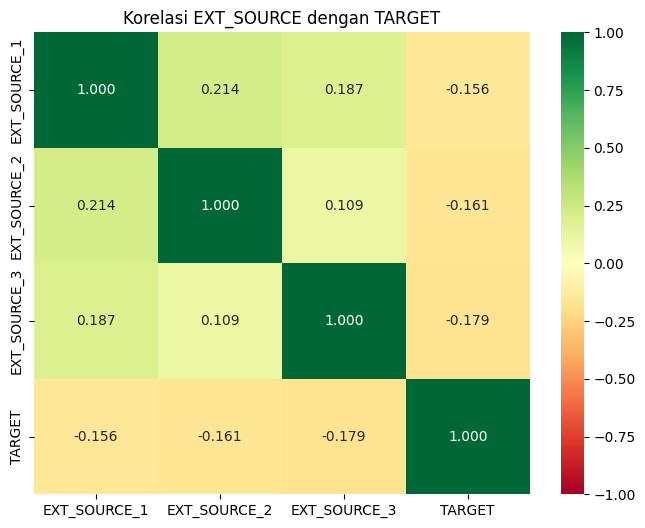

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

ext_data = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'TARGET']]
ext_corr = ext_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(ext_corr, annot=True, cmap='RdYlGn', vmin=-1, vmax=1, fmt='.3f')
plt.title('Korelasi EXT_SOURCE dengan TARGET')
plt.show()

In [ ]:
for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    df[f'{col}_MISSING'] = df[col].isna().astype(int)
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 306207 entries, 0 to 307510
Data columns (total 58 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   SK_ID_CURR                   306207 non-null  int32  
 1   TARGET                       306207 non-null  int8   
 2   NAME_CONTRACT_TYPE           306207 non-null  object 
 3   CODE_GENDER                  306207 non-null  object 
 4   CNT_CHILDREN                 306207 non-null  int8   
 5   AMT_INCOME_TOTAL             306207 non-null  float32
 6   AMT_CREDIT                   306207 non-null  float32
 7   AMT_ANNUITY                  306207 non-null  float32
 8   NAME_TYPE_SUITE              306207 non-null  object 
 9   NAME_INCOME_TYPE             306207 non-null  object 
 10  NAME_EDUCATION_TYPE          306207 non-null  object 
 11  NAME_FAMILY_STATUS           306207 non-null  object 
 12  NAME_HOUSING_TYPE            306207 non-null  object 
 13  REGI

## 2.9. Fill NA: All Num Features

In [ ]:
# Numerik
print(df[['APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG',
          'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG',
          'LANDAREA_AVG', 'NONLIVINGAREA_AVG', 'TARGET']].corr()['TARGET'])

# Kategorikal - cek default rate per kategori
for col in ['HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']:
    print(f"\n{col}:")
    print(df.groupby(col)['TARGET'].mean().sort_values())

APARTMENTS_AVG                -0.029335
BASEMENTAREA_AVG              -0.022601
YEARS_BEGINEXPLUATATION_AVG   -0.009402
ELEVATORS_AVG                 -0.033926
ENTRANCES_AVG                 -0.019111
FLOORSMAX_AVG                 -0.043896
LANDAREA_AVG                  -0.010794
NONLIVINGAREA_AVG             -0.013522
TARGET                         1.000000
Name: TARGET, dtype: float64

HOUSETYPE_MODE:
HOUSETYPE_MODE
block of flats      0.069575
terraced house      0.085477
specific housing    0.100604
Name: TARGET, dtype: float64

WALLSMATERIAL_MODE:
WALLSMATERIAL_MODE
Monolithic      0.047538
Panel           0.063580
Block           0.070444
Stone, brick    0.074242
Mixed           0.075241
Others          0.082767
Wooden          0.097287
Name: TARGET, dtype: float64

EMERGENCYSTATE_MODE:
EMERGENCYSTATE_MODE
No     0.069791
Yes    0.095914
Name: TARGET, dtype: float64


In [ ]:
for col in ['APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG',
            'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG',
            'LANDAREA_AVG', 'NONLIVINGAREA_AVG']:
    df[f'{col}_MISSING'] = df[col].isna().astype(int)
    df[col] = df[col].fillna(df[col].median())

In [ ]:
for col in ['HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']:
    df[col] = df[col].fillna('Unknown')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 306207 entries, 0 to 307510
Data columns (total 66 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   SK_ID_CURR                           306207 non-null  int32  
 1   TARGET                               306207 non-null  int8   
 2   NAME_CONTRACT_TYPE                   306207 non-null  object 
 3   CODE_GENDER                          306207 non-null  object 
 4   CNT_CHILDREN                         306207 non-null  int8   
 5   AMT_INCOME_TOTAL                     306207 non-null  float32
 6   AMT_CREDIT                           306207 non-null  float32
 7   AMT_ANNUITY                          306207 non-null  float32
 8   NAME_TYPE_SUITE                      306207 non-null  object 
 9   NAME_INCOME_TYPE                     306207 non-null  object 
 10  NAME_EDUCATION_TYPE                  306207 non-null  object 
 11  NAME_FAMILY_STATUS

## 2.10. Drop Row: Social_Circle

In [ ]:
cols_drop_row = ['OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
                 'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE']

df = df.dropna(subset=cols_drop_row)
print(df.shape)

(305185, 66)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 305185 entries, 0 to 307510
Data columns (total 66 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   SK_ID_CURR                           305185 non-null  int32  
 1   TARGET                               305185 non-null  int8   
 2   NAME_CONTRACT_TYPE                   305185 non-null  object 
 3   CODE_GENDER                          305185 non-null  object 
 4   CNT_CHILDREN                         305185 non-null  int8   
 5   AMT_INCOME_TOTAL                     305185 non-null  float32
 6   AMT_CREDIT                           305185 non-null  float32
 7   AMT_ANNUITY                          305185 non-null  float32
 8   NAME_TYPE_SUITE                      305185 non-null  object 
 9   NAME_INCOME_TYPE                     305185 non-null  object 
 10  NAME_EDUCATION_TYPE                  305185 non-null  object 
 11  NAME_FAMILY_STATUS

## 2.11. Fill NA: AM_REQ_BUREAU

In [ ]:
print(df[df['AMT_REQ_CREDIT_BUREAU_YEAR'].isna()]['TARGET'].mean())
print(df[df['AMT_REQ_CREDIT_BUREAU_YEAR'].notna()]['TARGET'].mean())

0.10356952325525001
0.07747009816364649


In [ ]:
cols_bureau = ['AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
               'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
               'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR']

# 1. Buat flag Missing (Sudah benar)
df['AMT_REQ_CREDIT_BUREAU_MISSING'] = df['AMT_REQ_CREDIT_BUREAU_YEAR'].isna().astype(int)

# 2. Buat fitur TOTAL sebelum diimputasi (Fitur ini sangat kuat!)
df['TOTAL_BUREAU_QUERIES'] = df[cols_bureau].sum(axis=1)

# 3. Imputasi (Saran: Gunakan 0 atau -1, median biasanya 0 juga)
for col in cols_bureau:
    df[col] = df[col].fillna(0) # Mengasumsikan jika NaN berarti tidak ada pengecekan

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 305185 entries, 0 to 307510
Data columns (total 68 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   SK_ID_CURR                           305185 non-null  int32  
 1   TARGET                               305185 non-null  int8   
 2   NAME_CONTRACT_TYPE                   305185 non-null  object 
 3   CODE_GENDER                          305185 non-null  object 
 4   CNT_CHILDREN                         305185 non-null  int8   
 5   AMT_INCOME_TOTAL                     305185 non-null  float32
 6   AMT_CREDIT                           305185 non-null  float32
 7   AMT_ANNUITY                          305185 non-null  float32
 8   NAME_TYPE_SUITE                      305185 non-null  object 
 9   NAME_INCOME_TYPE                     305185 non-null  object 
 10  NAME_EDUCATION_TYPE                  305185 non-null  object 
 11  NAME_FAMILY_STATUS

## 2.12. Detect Duplicate Row

In [ ]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate SK_ID_CURR:", df['SK_ID_CURR'].duplicated().sum())
df = df.drop_duplicates()

Duplicate rows: 0
Duplicate SK_ID_CURR: 0


## 2.13. Detect Anomali: DAYS_EMPLOYED 365243 = Pengangguran

In [ ]:
# DAYS_EMPLOYED punya anomali terkenal di dataset ini
print(df['DAYS_EMPLOYED'].value_counts().head(10))
print((df['DAYS_EMPLOYED'] == 365243).sum())

DAYS_EMPLOYED
 365243    55006
-200         154
-199         150
-224         149
-212         147
-230         147
-229         142
-384         141
-231         140
-215         138
Name: count, dtype: int64
55006


In [ ]:
print(df[df['DAYS_EMPLOYED'] == 365243]['TARGET'].mean())
print(df[df['DAYS_EMPLOYED'] != 365243]['TARGET'].mean())

0.05406682907319202
0.0869177668789147


In [ ]:

df['DAYS_EMPLOYED_ANOMALY'] = (df['DAYS_EMPLOYED'] == 365243).astype('int8')
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, 0)

print(df['DAYS_EMPLOYED'].max())  # pastikan 365243 sudah tidak ada
print(df['DAYS_EMPLOYED_ANOMALY'].value_counts())

0
DAYS_EMPLOYED_ANOMALY
0    250179
1     55006
Name: count, dtype: int64


In [ ]:
df.describe()

/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:731: RuntimeWarning: invalid value encountered in scalar divide
  the_mean = the_sum / count if count > 0 else np.nan
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow enco

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,LANDAREA_AVG,NONLIVINGAREA_AVG,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,TOTAL_FLAGS,EXT_SOURCE_1_MISSING,EXT_SOURCE_2_MISSING,EXT_SOURCE_3_MISSING,APARTMENTS_AVG_MISSING,BASEMENTAREA_AVG_MISSING,YEARS_BEGINEXPLUATATION_AVG_MISSING,ELEVATORS_AVG_MISSING,ENTRANCES_AVG_MISSING,FLOORSMAX_AVG_MISSING,LANDAREA_AVG_MISSING,NONLIVINGAREA_AVG_MISSING,AMT_REQ_CREDIT_BUREAU_MISSING,TOTAL_BUREAU_QUERIES,DAYS_EMPLOYED_ANOMALY
count,305185.000000,305185.000000,305185.000000,3.051850e+05,3.051850e+05,305185.000000,305185.000000,305185.000000,305185.000000,305185.0,305185.000000,305185.0,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,3.051850e+05,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.0,305185.000000,305185.000000,305185.0,305185.000000,305185.000000,305185.00000,305185.0,305185.0,305185.0,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.0,305185.000000
mean,278164.198650,0.080997,0.417150,1.686140e+05,5.992816e+05,27136.761719,0.000000,-16041.650124,-1955.556017,NaN,-2994.648620,NaN,2.053266,12.059413,0.015161,0.050704,0.040543,0.078208,0.230654,0.179724,NaN,NaN,NaN,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.000000,0.000000,0.00000,NaN,NaN,NaN,4.502744,0.563907,0.002143,0.198165,0.508007,0.585661,0.488340,0.533542,0.504025,0.498147,0.594223,0.552357,0.135125,NaN,0.180238
std,102784.522248,0.272831,0.722267,2.377228e+05,4.019861e+05,14474.180664,0.013809,4362.501707,2307.937739,0.0,1509.345504,0.0,0.508841,3.265809,0.122194,0.219392,0.197228,0.268500,0.421252,0.383958,0.000000,0.000000e+00,0.000000,0.077271,0.053253,0.000000,0.099915,0.070679,0.106567,0.052399,0.048004,0.0,0.446777,0.362305,0.0,0.078003,0.102844,0.19104,0.0,0.0,0.0,1.006350,0.495900,0.046243,0.398618,0.499937,0.492608,0.499865,0.498874,0.499985,0.499997,0.491043,0.497252,0.341857,0.0,0.384386
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,0.000290,-25229.000000,-17912.000000,-24672.0,-7197.000000,1.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.014565,5.960464e-08,0.000527,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,-4292.0,0.000000,0.000000,0.00000,0.0,0.0,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,189129.000000,0.000000,0.000000,1.125000e+05,2.700000e+05,16573.500000,0.010010,-19685.000000,-2761.000000,-7480.0,-4299.000000,2.0,2.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.505859,3.925781e-01,0.416992,0.087585,0.076294,0.981445,0.000000,0.137939,0.166748,0.048096,0.003599,0.0,0.000000,0.000000,-1572.0,0.000000,0.000000,0.00000,0.0,0.0,0.0,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
50%,278189.000000,0.000000,0.000000,1.458000e+05,5.147775e+05,24939.000000,0.018845,-15756.000000,-1214.000000,-4

In [ ]:
float16_cols = df.select_dtypes(include='float16').columns
df[float16_cols] = df[float16_cols].astype('float32')
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,LANDAREA_AVG,NONLIVINGAREA_AVG,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,TOTAL_FLAGS,EXT_SOURCE_1_MISSING,EXT_SOURCE_2_MISSING,EXT_SOURCE_3_MISSING,APARTMENTS_AVG_MISSING,BASEMENTAREA_AVG_MISSING,YEARS_BEGINEXPLUATATION_AVG_MISSING,ELEVATORS_AVG_MISSING,ENTRANCES_AVG_MISSING,FLOORSMAX_AVG_MISSING,LANDAREA_AVG_MISSING,NONLIVINGAREA_AVG_MISSING,AMT_REQ_CREDIT_BUREAU_MISSING,TOTAL_BUREAU_QUERIES,DAYS_EMPLOYED_ANOMALY
count,305185.000000,305185.000000,305185.000000,3.051850e+05,3.051850e+05,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,3.051850e+05,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000
mean,278164.198650,0.080997,0.417150,1.686140e+05,5.992816e+05,27136.761719,0.020845,-16041.650124,-1955.556017,-4987.875977,-2994.648620,2.153127,2.053266,12.059413,0.015161,0.050704,0.040543,0.078208,0.230654,0.179724,0.504193,5.143310e-01,0.515663,0.102225,0.081301,0.979534,0.036746,0.143764,0.196526,0.055474,0.014647,1.421620,0.143395,0.100025,-965.039124,0.005515,0.006055,0.029828,0.231479,0.229943,1.647558,4.502744,0.563907,0.002143,0.198165,0.508007,0.585661,0.488340,0.533542,0.504025,0.498147,0.594223,0.552357,0.135125,2.150378,0.180238
std,102784.522248,0.272831,0.722267,2.377228e+05,4.019861e+05,14474.180664,0.013813,4362.501707,2307.937739,3522.206543,1509.345504,0.911597,0.508841,3.265809,0.122194,0.219392,0.197228,0.268500,0.421252,0.383958,0.139390,1.909246e-01,0.174739,0.077325,0.053261,0.042408,0.099955,0.070683,0.106588,0.052412,0.048005,2.398928,0.446462,0.362463,826.988525,0.077751,0.102822,0.191095,0.854982,0.744987,1.855713,1.006350,0.495900,0.046243,0.398618,0.499937,0.492608,0.499865,0.498874,0.499985,0.499997,0.491043,0.497252,0.341857,2.291530,0.384386
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,0.000290,-25229.000000,-17912.000000,-24672.000000,-7197.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.014565,5.960464e-08,0.000527,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4292.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189129.000000,0.000000,0.000000,1.125000e+05,2.700000e+05,16573.500000,0.010010,-19685.000000,-2761.000000,-7480.000000,-4299.000000,2.000000,2.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.505859,3.925781e-01,0.416992,0.087585,0.076294,0.981445,0.000000,0.137939,0.166748,0.048096,0.003599,0.000000,0.000000,0.000000,-1572.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.00000

## 2.14. Capping: Income, Circle, Credit, Anak, dan Jumlah Anggota Keluarga

**Before**

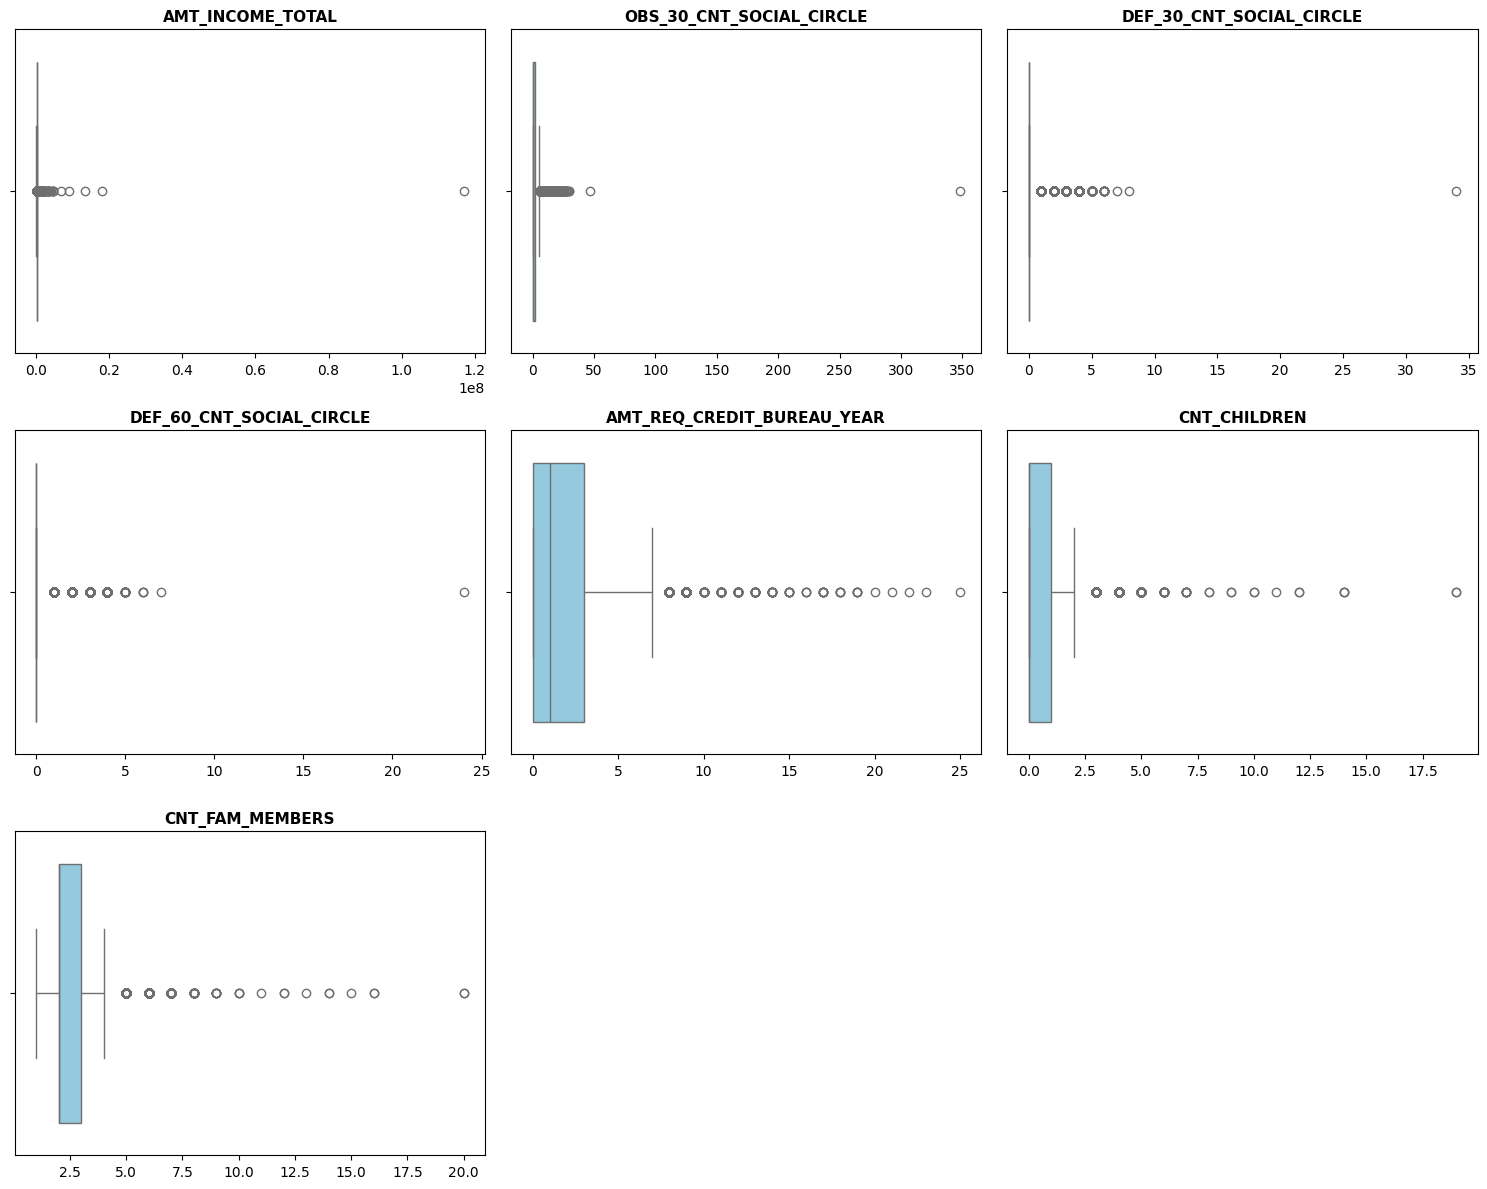

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


capped_cols = [
    'AMT_INCOME_TOTAL', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
    'DEF_60_CNT_SOCIAL_CIRCLE', 'AMT_REQ_CREDIT_BUREAU_YEAR',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS'
]


cols_to_plot = [col for col in capped_cols if col in df.columns]

n_cols = 3
n_rows = (len(cols_to_plot) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
cap_config = {
    'AMT_INCOME_TOTAL': 0.99,
    'OBS_30_CNT_SOCIAL_CIRCLE': 0.98,
    'DEF_30_CNT_SOCIAL_CIRCLE': 0.98,
    'DEF_60_CNT_SOCIAL_CIRCLE': 0.98,
    'AMT_REQ_CREDIT_BUREAU_YEAR': 0.99,
    'CNT_CHILDREN': 0.995,
    'CNT_FAM_MEMBERS': 0.995
}

for col, q in cap_config.items():
    if col in df.columns:
        cap_val = df[col].quantile(q)
        df[col] = df[col].clip(upper=cap_val)

        # kalau integer → bulatkan
        if pd.api.types.is_integer_dtype(df[col]):
            df[col] = df[col].round()

        print(f"{col} capped at {q*100:.1f} percentile → {cap_val:.2f}")

AMT_INCOME_TOTAL capped at 99.0 percentile → 454500.00
OBS_30_CNT_SOCIAL_CIRCLE capped at 98.0 percentile → 9.00
DEF_30_CNT_SOCIAL_CIRCLE capped at 98.0 percentile → 2.00
DEF_60_CNT_SOCIAL_CIRCLE capped at 98.0 percentile → 1.00
AMT_REQ_CREDIT_BUREAU_YEAR capped at 99.0 percentile → 8.00
CNT_CHILDREN capped at 99.5 percentile → 3.00
CNT_FAM_MEMBERS capped at 99.5 percentile → 5.00


**After**

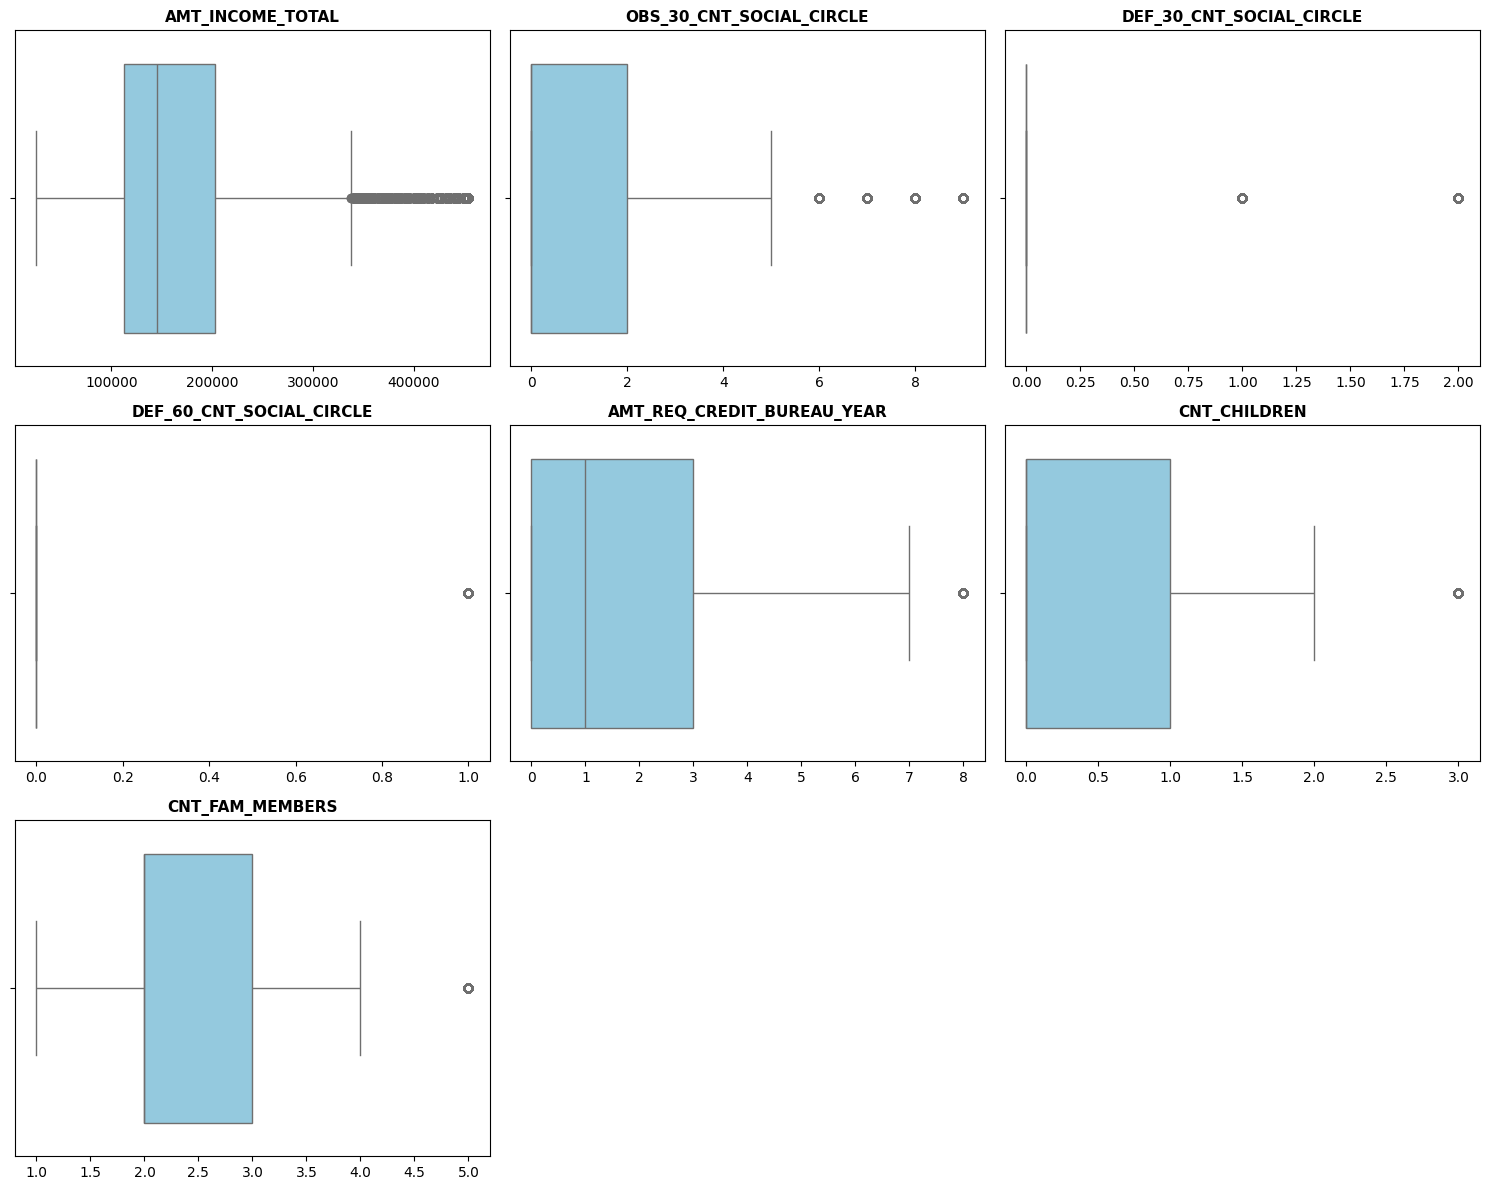

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


capped_cols = [
    'AMT_INCOME_TOTAL', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
    'DEF_60_CNT_SOCIAL_CIRCLE', 'AMT_REQ_CREDIT_BUREAU_YEAR',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS'
]


cols_to_plot = [col for col in capped_cols if col in df.columns]

n_cols = 3
n_rows = (len(cols_to_plot) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 2.15. Feature Engineering



### 🛠️ Feature Engineering & Data Transformation

Berikut adalah rincian rekayasa fitur baru dan transformasi data yang dilakukan untuk mengoptimalkan performa model:

| Nama Fitur Baru | Penjelasan |
| :--- | :--- |
| **`CREDIT_INCOME_RATIO`** | Rasio antara total plafon kredit (`AMT_CREDIT`) dengan pendapatan tahunan (`AMT_INCOME_TOTAL`). Mengukur seberapa besar beban hutang nasabah dibandingkan dengan kapasitas penghasilannya. |
| **`ANNUITY_INCOME_RATIO`** | Rasio antara besaran cicilan/anuitas (`AMT_ANNUITY`) dengan pendapatan tahunan. Berfungsi sebagai *Debt-to-Income Ratio* untuk melihat persentase gaji yang habis untuk membayar cicilan. |
| **`AGE`** | Hasil konversi dari kolom `DAYS_BIRTH` (berupa hari negatif) menjadi usia riil dalam hitungan tahun. Membuat data jauh lebih intuitif untuk dianalisis. |
| **`EMPLOYED_BIRTH_RATIO`** | Rasio perbandingan antara lama masa kerja (`DAYS_EMPLOYED`) dengan usia nasabah (`DAYS_BIRTH`). Sangat berguna untuk mengukur stabilitas karir nasabah di masa produktifnya. |
| **`AMT_INCOME_TOTAL`** *(Log-Transform)* | Transformasi logaritmik (`np.log1p`) pada pendapatan untuk menormalkan distribusi data yang sangat condong ke kanan (*right-skewed*) akibat rentang gaji ekstrem. |
| **`AMT_CREDIT`** *(Log-Transform)* | Transformasi logaritmik (`np.log1p`) pada plafon kredit untuk memampatkan rentang nilai yang terlalu masif agar lebih stabil saat dipelajari oleh model. |
| **`AMT_ANNUITY`** *(Log-Transform)* | Transformasi logaritmik (`np.log1p`) pada nominal cicilan untuk menyeimbangkan bentuk distribusi datanya. |
| **`CREDIT_INCOME_RATIO`** *(Log-Transform)* | Transformasi logaritmik (`np.log1p`) pada rasio kredit agar distribusinya lebih simetris dan aman dari *outlier*. |
| **`AMT_REQ_CREDIT_BUREAU_QRT`** *(Capped)* | Pembatasan nilai batas atas (*capping*) pada persentil ke-99. Tujuannya untuk memotong nilai ekstrem dari nasabah dengan riwayat pengecekan biro kredit tak wajar dalam satu kuartal. |

In [ ]:
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
df['AGE'] = (-df['DAYS_BIRTH']) / 365
df['EMPLOYED_BIRTH_RATIO'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']

In [ ]:
df['AMT_INCOME_TOTAL'] = np.log1p(df['AMT_INCOME_TOTAL'])
df['AMT_CREDIT'] = np.log1p(df['AMT_CREDIT'])
df['AMT_ANNUITY'] = np.log1p(df['AMT_ANNUITY'])
df['CREDIT_INCOME_RATIO'] = np.log1p(df['CREDIT_INCOME_RATIO'])

In [ ]:
df['AMT_REQ_CREDIT_BUREAU_QRT'] = np.clip(
    df['AMT_REQ_CREDIT_BUREAU_QRT'],
    None,
    df['AMT_REQ_CREDIT_BUREAU_QRT'].quantile(0.99)
)

In [ ]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,LANDAREA_AVG,NONLIVINGAREA_AVG,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,TOTAL_FLAGS,EXT_SOURCE_1_MISSING,EXT_SOURCE_2_MISSING,EXT_SOURCE_3_MISSING,APARTMENTS_AVG_MISSING,BASEMENTAREA_AVG_MISSING,YEARS_BEGINEXPLUATATION_AVG_MISSING,ELEVATORS_AVG_MISSING,ENTRANCES_AVG_MISSING,FLOORSMAX_AVG_MISSING,LANDAREA_AVG_MISSING,NONLIVINGAREA_AVG_MISSING,AMT_REQ_CREDIT_BUREAU_MISSING,TOTAL_BUREAU_QUERIES,DAYS_EMPLOYED_ANOMALY,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,AGE,EMPLOYED_BIRTH_RATIO
count,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,3.051850e+05,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000,305185.000000
mean,278164.198650,0.080997,0.414490,11.904921,13.070833,10.069266,0.020845,-16041.650124,-1955.556017,-4987.875977,-2994.648620,2.150587,2.053266,12.059413,0.015161,0.050704,0.040543,0.078208,0.230654,0.179724,0.504193,5.143310e-01,0.515663,0.102225,0.081301,0.979534,0.036746,0.143764,0.196526,0.055474,0.014647,1.377348,0.137022,0.084057,-965.039124,0.005515,0.006055,0.029828,0.231479,0.219149,1.641735,4.502744,0.563907,0.002143,0.198165,0.508007,0.585661,0.488340,0.533542,0.504025,0.498147,0.594223,0.552357,0.135125,2.150378,0.180238,1.478489,0.181608,43.949726,0.128637
std,102784.522248,0.272831,0.707183,0.477090,0.714975,0.544940,0.013813,4362.501707,2307.937739,3522.206543,1509.345504,0.897774,0.508841,3.265809,0.122194,0.219392,0.197228,0.268500,0.421252,0.383958,0.139390,1.909246e-01,0.174739,0.077325,0.053261,0.042408,0.099955,0.070683,0.106588,0.052412,0.048005,2.111965,0.404078,0.277685,826.988525,0.077751,0.102822,0.191095,0.854982,0.528556,1.831330,1.006350,0.495900,0.046243,0.398618,0.499937,0.492608,0.499865,0.498874,0.499985,0.499997,0.491043,0.497252,0.341857,2.291530,0.384386,0.493291,0.094454,11.952059,0.135159
min,100002.000000,0.000000,0.000000,10.152338,10.714440,7.388019,0.000290,-25229.000000,-17912.000000,-24672.000000,-7197.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.014565,5.960464e-08,0.000527,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4292.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.094410,0.008700,20.517808,-0.000000
25%,189129.000000,0.000000,0.000000,11.630717,12.506181,9.715621,0.010010,-19685.000000,-2761.000000,-7480.000000,-4299.000000,2.000000,2.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.505859

### 🗓️ Konversi Format Waktu & Pembersihan Fitur Redundan

Data bawaan Home Credit banyak menggunakan format waktu berupa "jumlah hari yang ditarik mundur" (bernilai negatif). Bagian ini bertujuan untuk mengubah format tersebut menjadi satuan **Tahun** yang positif dan lebih intuitif, dengan pembagi `-365.25` (untuk mengakomodasi tahun kabisat).

| Nama Fitur / Tindakan | Penjelasan |
| :--- | :--- |
| **`YEARS_EMPLOYED`** | Konversi dari `DAYS_EMPLOYED` menjadi masa kerja dalam satuan tahun riil. Membuat model lebih mudah mencerna profil senioritas pekerja. |
| **`YEARS_REGISTRATION`** | Konversi dari `DAYS_REGISTRATION` menjadi hitungan tahun sejak nasabah mengubah data registrasi/domisili terakhirnya. |
| **`YEARS_ID_PUBLISH`** | Konversi dari `DAYS_ID_PUBLISH` menjadi hitungan tahun sejak dokumen identitas (seperti KTP) diterbitkan atau diganti. |
| **`YEARS_LAST_PHONE_CHANGE`** | Konversi dari `DAYS_LAST_PHONE_CHANGE` menjadi hitungan tahun sejak nasabah terakhir kali mengganti nomor telepon. |
| **Drop Kolom Redundan (`DAYS_...`)** | Menghapus kolom asli (`DAYS_BIRTH`, `DAYS_EMPLOYED`, `DAYS_REGISTRATION`, dll.) karena informasinya sudah sepenuhnya terwakili oleh fitur baru. Ini penting untuk mencegah *multicollinearity* (informasi ganda) dan memperingan beban komputasi model. |

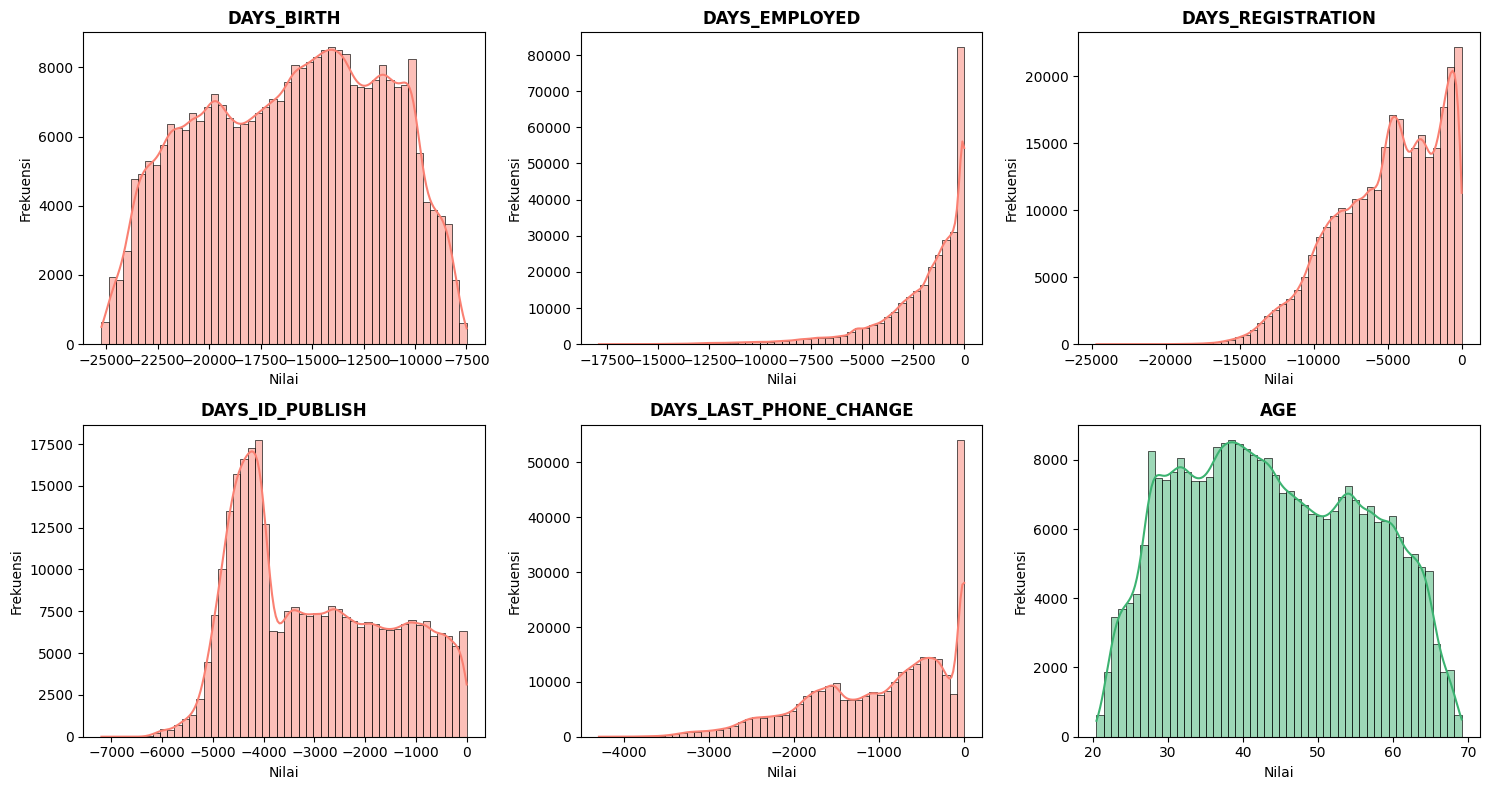

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================
# 1. DEFINISIKAN SEMUA KEMUNGKINAN KOLOM (HARI & TAHUN)
# ====================================================
kolom_waktu = [
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE',
    'AGE', 'YEARS_EMPLOYED', 'YEARS_REGISTRATION', 'YEARS_ID_PUBLISH', 'YEARS_LAST_PHONE_CHANGE'
]

# Deteksi otomatis kolom mana yang saat ini benar-benar ada di dataframe
kolom_tersedia = [col for col in kolom_waktu if col in df.columns]

# ====================================================
# 2. PERSIAPAN KANVAS & MENGGAMBAR GRAFIK (GRID)
# ====================================================
# Siapkan grid (misal maksimal 3 grafik per baris agar rapi)
n_cols = 3
n_rows = (len(kolom_tersedia) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten() # Ratakan array agar mudah dilooping

# Looping untuk menggambar histogram pada setiap kolom yang tersedia
for i, col in enumerate(kolom_tersedia):
    # Gunakan warna berbeda otomatis: Merah untuk DAYS (sebelum), Hijau untuk YEARS/AGE (sesudah)
    warna = 'salmon' if 'DAYS' in col else 'mediumseagreen'

    sns.histplot(df[col], bins=50, kde=True, ax=axes[i], color=warna)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')

# Hapus sisa kanvas kosong (jika jumlah kolom tidak pas kelipatan 3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# 1. Konversi sisa kolom DAYS_ menjadi Tahun (Positif)
# Ingat, kita membagi dengan -365.25 (memperhitungkan tahun kabisat)
df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED'] / -365.25
df['YEARS_REGISTRATION'] = df['DAYS_REGISTRATION'] / -365.25
df['YEARS_ID_PUBLISH'] = df['DAYS_ID_PUBLISH'] / -365.25

# Cek apakah ada kolom DAYS_LAST_PHONE_CHANGE, jika ada konversi juga
if 'DAYS_LAST_PHONE_CHANGE' in df.columns:
    df['YEARS_LAST_PHONE_CHANGE'] = df['DAYS_LAST_PHONE_CHANGE'] / -365.25
    cols_to_drop_phone = ['DAYS_LAST_PHONE_CHANGE']
else:
    cols_to_drop_phone = []

# 2. Sekarang, HAPUS semua kolom DAYS_ aslinya
cols_to_drop = [
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'DAYS_REGISTRATION',
    'DAYS_ID_PUBLISH'
] + cols_to_drop_phone

df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print(f"Konversi selesai dan kolom redundan dihapus. Jumlah fitur saat ini: {len(df.columns)}")

Konversi selesai dan kolom redundan dihapus. Jumlah fitur saat ini: 72


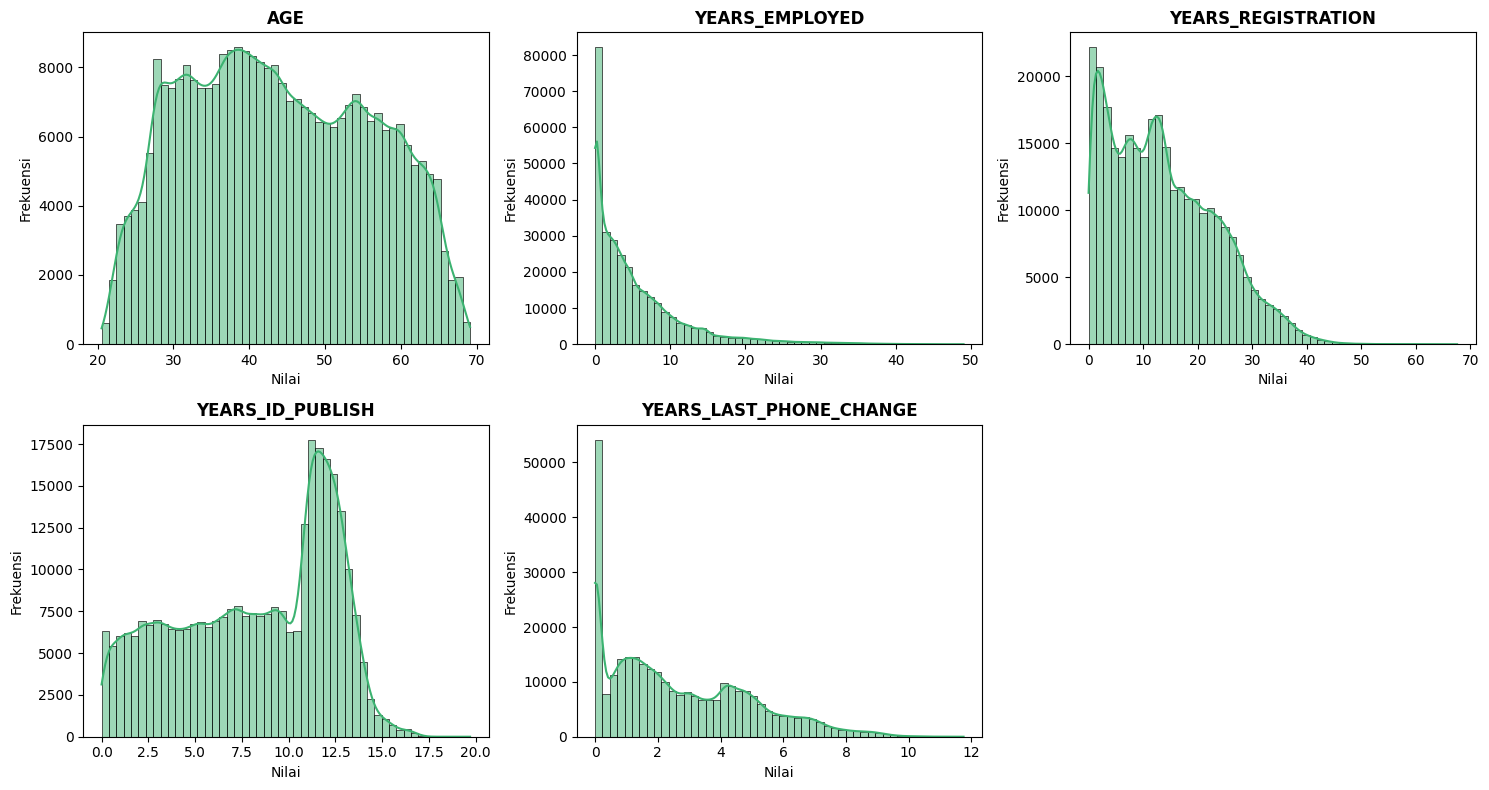

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================
# 1. DEFINISIKAN SEMUA KEMUNGKINAN KOLOM (HARI & TAHUN)
# ====================================================
kolom_waktu = [
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE',
    'AGE', 'YEARS_EMPLOYED', 'YEARS_REGISTRATION', 'YEARS_ID_PUBLISH', 'YEARS_LAST_PHONE_CHANGE'
]

# Deteksi otomatis kolom mana yang saat ini benar-benar ada di dataframe
kolom_tersedia = [col for col in kolom_waktu if col in df.columns]

# ====================================================
# 2. PERSIAPAN KANVAS & MENGGAMBAR GRAFIK (GRID)
# ====================================================
# Siapkan grid (misal maksimal 3 grafik per baris agar rapi)
n_cols = 3
n_rows = (len(kolom_tersedia) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten() # Ratakan array agar mudah dilooping

# Looping untuk menggambar histogram pada setiap kolom yang tersedia
for i, col in enumerate(kolom_tersedia):
    # Gunakan warna berbeda otomatis: Merah untuk DAYS (sebelum), Hijau untuk YEARS/AGE (sesudah)
    warna = 'salmon' if 'DAYS' in col else 'mediumseagreen'

    sns.histplot(df[col], bins=50, kde=True, ax=axes[i], color=warna)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')

# Hapus sisa kanvas kosong (jika jumlah kolom tidak pas kelipatan 3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# **3.&nbsp;First Iteration**

## 3.1. Create X Y

In [ ]:
X = df.drop(columns=['TARGET', 'SK_ID_CURR'], errors='ignore')
y = df['TARGET']

## 3.2. Encoding

In [ ]:
cat_cols = X.select_dtypes(include='object').columns
print("Categorical columns:", list(cat_cols))

Categorical columns: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [ ]:
X = pd.get_dummies(X, columns=cat_cols)

## 3.3. Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## 3.4. Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3.5. Modelling

### 3.5.1. Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

model_lr = LogisticRegression(
    max_iter=3000,
    class_weight='balanced',
    random_state=42
)

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict_proba(X_test_scaled)[:, 1]
auc_lr = roc_auc_score(y_test, y_pred_lr)

print(f"AUC Logistic Regression: {auc_lr:.4f}")

AUC Logistic: 0.7285


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


### 3.5.2. LightBM

In [ ]:
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

In [ ]:
from lightgbm import LGBMClassifier

model_lgb = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=42
)

model_lgb.fit(X_train, y_train)

y_pred_lgb = model_lgb.predict_proba(X_test)[:, 1]
auc_lgb = roc_auc_score(y_test, y_pred_lgb)

print(f"AUC LightGBM: {auc_lgb:.4f}")

[LightGBM] [Info] Number of positive: 19775, number of negative: 224373
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.135035 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5614
[LightGBM] [Info] Number of data points in the train set: 244148, number of used features: 187
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
AUC LightGBM: 0.7545


# **4.&nbsp;Second Iteration**

## 4.1. Split

In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

## 4.2. Hyperparameter Tuning: Optuna Method



In [ ]:
!pip install optuna

In [ ]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'class_weight': 'balanced',
        'random_state': 42
    }

    model = LGBMClassifier(**params)

    model.fit(X_tr, y_tr)

    y_pred = model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, y_pred)

    return auc

In [ ]:
study = optuna.create_study(direction='maximize')

study.optimize(objective, n_trials=20)

[I 2026-04-03 09:33:37,039] A new study created in memory with name: no-name-6ae1abf7-347c-456e-b6fa-320acaec9ffc


[LightGBM] [Info] Number of positive: 15820, number of negative: 179498
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.196631 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5705
[LightGBM] [Info] Number of data points in the train set: 195318, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-04-03 09:34:23,538] Trial 0 finished with value: 0.7500970148149975 and parameters: {'n_estimators': 764, 'learning_rate': 0.033299382485949484, 'num_leaves': 87, 'max_depth': 3, 'min_child_samples': 54, 'subsample': 0.8956074838660801, 'colsample_bytree': 0.8466218959436338}. Best is trial 0 with value: 0.7500970148149975.


[LightGBM] [Info] Number of positive: 15820, number of negative: 179498
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.107714 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5705
[LightGBM] [Info] Number of data points in the train set: 195318, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-04-03 09:35:03,418] Trial 1 finished with value: 0.7391194503625396 and parameters: {'n_estimators': 776, 'learning_rate': 0.09274176113587058, 'num_leaves': 50, 'max_depth': 6, 'min_child_samples': 47, 'subsample': 0.7321215403412331, 'colsample_bytree': 0.6898861628328431}. Best is trial 0 with value: 0.7500970148149975.


...

[I 2026-04-03 09:46:30,475] Trial 17 finished with value: 0.7343912103081675 and parameters: {'n_estimators': 664, 'learning_rate': 0.0750548219718312, 'num_leaves': 76, 'max_depth': 8, 'min_child_samples': 34, 'subsample': 0.8699247882831318, 'colsample_bytree': 0.8714675596536081}. Best is trial 9 with value: 0.7516674904655085.


[LightGBM] [Info] Number of positive: 15820, number of negative: 179498
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.112176 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5703
[LightGBM] [Info] Number of data points in the train set: 195318, number of used features: 182
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-04-03 09:47:12,995] Trial 18 finished with value: 0.7507338505259377 and parameters: {'n_estimators': 926, 'learning_rate': 0.0199938352112961, 'num_leaves': 60, 'max_depth': 4, 'min_child_samples': 66, 'subsample': 0.9754209630439399, 'colsample_bytree': 0.9590301561431891}. Best is trial 9 with value: 0.7516674904655085.


[LightGBM] [Info] Number of positive: 15820, number of negative: 179498
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.115917 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5705
[LightGBM] [Info] Number of data points in the train set: 195318, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


[I 2026-04-03 09:47:44,311] Trial 19 finished with value: 0.7512987797963863 and parameters: {'n_estimators': 474, 'learning_rate': 0.03856939733196293, 'num_leaves': 37, 'max_depth': 10, 'min_child_samples': 52, 'subsample': 0.9372644143170538, 'colsample_bytree': 0.7870204839205021}. Best is trial 9 with value: 0.7516674904655085.


Trial 9 finished with value: 0.7516674904655085 and parameters: {'n_estimators': 900, 'learning_rate': 0.036753688375282104, 'num_leaves': 35, 'max_depth': 5, 'min_child_samples': 49, 'subsample': 0.9297761206843986, 'colsample_bytree': 0.9726991682189456}..

* Best is trial 9 with value: Best is trial 9 with value: 0.7516674904655085..

Hasil Optuna masih lebih rendah dari hasil model sebelumnya.
* Logistic Regression: 0.7285
* LightGBM: 0.7545
* LightGBM Optuna: 0.7526 (validation)

# **5.&nbsp;Third Iteration**

## 5.1 FE: Credit Term

CREDIT_TERM: Menghitung rasio beban tahunan terhadap total pinjaman. Di industri, ini membantu model memahami seberapa besar cicilan memberatkan total utang; rasio tinggi biasanya menandakan jangka waktu pinjaman yang pendek atau bunga yang tinggi.

In [ ]:
df['CREDIT_TERM'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']

## 5.2 FE: Income per Person

INCOME_PER_PERSON: Mengukur daya beli riil per anggota keluarga. Seseorang dengan gaji 10 juta tapi menanggung 5 orang memiliki profil risiko yang berbeda dengan lajang dengan gaji yang sama.

In [ ]:
df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']

## 5.3 FE: Credit per Person

CREDIT_PER_PERSON: Melihat beban utang yang "ditanggung" secara kolektif oleh anggota keluarga. Ini memberikan perspektif tentang standar hidup dan eksposur risiko keluarga tersebut

In [ ]:
df['CREDIT_PER_PERSON'] = df['AMT_CREDIT'] / df['CNT_FAM_MEMBERS']

## 5.4 FE: Ext Source Mean



EXT_SOURCE_MEAN: Menggabungkan skor dari sumber eksternal (biasanya skor kredit dari biro lain) menjadi satu nilai rata-rata. Ini menstabilkan sinyal jika salah satu sumber data memiliki noise atau hilang (null).

In [ ]:
df['EXT_SOURCE_MEAN'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)

## 5.5 FE: Ext Source STD



EXT_SOURCE_STD: Menghitung standar deviasi (variansi) antar skor eksternal. Jika nilainya tinggi, berarti ada inkonsistensi data antar lembaga kredit, yang bisa menjadi indikasi risiko tersendiri.

In [ ]:
df['EXT_SOURCE_STD'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].std(axis=1)

## 5.6 FE: Ext Source Product


EXT_SOURCE_PRODUCT: Perkalian antar skor eksternal. Teknik ini sering digunakan untuk memberikan penalti berat jika salah satu skor sangat rendah, karena hasil perkalian akan langsung anjlok secara drastis.

In [ ]:
df['EXT_SOURCE_PRODUCT'] = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']

## 5.7 FE: Property Score


PROPERTY_SCORE: Merangkum berbagai informasi aset (apartemen, lift, lantai) menjadi satu indeks kesejahteraan. Daripada model mempelajari 5 kolom properti secara terpisah, satu skor agregat seringkali lebih "bertenaga".

In [ ]:
property_cols = [
    'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'ELEVATORS_AVG',
    'ENTRANCES_AVG', 'FLOORSMAX_AVG'
]

df['PROPERTY_SCORE'] = df[property_cols].mean(axis=1)

## 5.8 FE: Has Children


HAS_CHILDREN: Mengubah jumlah anak (numerik) menjadi kategori biner (punya/tidak). Seringkali, perbedaan perilaku keuangan lebih terlihat pada "apakah seseorang punya anak" daripada "apakah dia punya 3 atau 4 anak".

In [ ]:
df['HAS_CHILDREN'] = (df['CNT_CHILDREN'] > 0).astype(int)

## 5.9 FE: High Credit


HIGH_CREDIT: Membuat threshold (ambang batas) risiko. Di sini kamu menentukan bahwa rasio pinjaman di atas 3 kali pendapatan adalah "High Credit" (risiko tinggi), yang mempermudah model melakukan klasifikasi cepat.

In [ ]:
df['HIGH_CREDIT'] = (df['CREDIT_INCOME_RATIO'] > 3).astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 305185 entries, 0 to 307510
Data columns (total 81 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   SK_ID_CURR                           305185 non-null  int32  
 1   TARGET                               305185 non-null  int8   
 2   NAME_CONTRACT_TYPE                   305185 non-null  object 
 3   CODE_GENDER                          305185 non-null  object 
 4   CNT_CHILDREN                         305185 non-null  int8   
 5   AMT_INCOME_TOTAL                     305185 non-null  float32
 6   AMT_CREDIT                           305185 non-null  float32
 7   AMT_ANNUITY                          305185 non-null  float32
 8   NAME_TYPE_SUITE                      305185 non-null  object 
 9   NAME_INCOME_TYPE                     305185 non-null  object 
 10  NAME_EDUCATION_TYPE                  305185 non-null  object 
 11  NAME_FAMILY_STATUS

## 5.10 FE: Age Income


AGE_INCOME (Interaction Feature): Mengalikan usia dengan total pendapatan. Secara industri, ini bisa dianggap sebagai proksi untuk "Life-time Wealth" atau potensi akumulasi aset. Seseorang yang lebih tua dengan pendapatan tinggi biasanya dianggap lebih stabil daripada orang muda dengan pendapatan yang sama karena asumsi kepemilikan aset yang lebih matang.

In [ ]:
df['AGE_INCOME'] = df['AGE'] * df['AMT_INCOME_TOTAL']

## 5.11 FE: Credit Age Ratio


CREDIT_AGE_RATIO: Melihat besarnya pinjaman dibandingkan dengan usia pemohon. Hal ini membantu mengidentifikasi apakah jumlah pinjaman tersebut "wajar" untuk tahap kehidupan mereka. Misalnya, pinjaman besar di usia sangat muda bisa dianggap sebagai risiko tinggi (over-leverage).

In [ ]:
df['CREDIT_AGE_RATIO'] = df['AMT_CREDIT'] / df['AGE']

## 5.12 FE: Employed Ratio


Drop EMPLOYED_BIRTH_RATIO: Ini adalah langkah Feature Selection. Saya membuang karena sepertinya lebih baik menggunakan tahun (umur) dibanding haris.

EMPLOYED_RATIO: Ini adalah fitur yang sangat kuat. Rasio lama bekerja terhadap usia menunjukkan stabilitas karier. Jika seseorang berusia 40 tahun tapi baru bekerja 2 tahun (rasio kecil), model akan menandai ini sebagai anomali atau risiko ketidakstabilan pekerjaan dibanding orang seusianya yang sudah bekerja 15 tahun.

In [ ]:
df.drop(columns=['EMPLOYED_BIRTH_RATIO'], inplace=True)
df['EMPLOYED_RATIO'] = df['YEARS_EMPLOYED'] / df['AGE']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 305185 entries, 0 to 307510
Data columns (total 83 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   SK_ID_CURR                           305185 non-null  int32  
 1   TARGET                               305185 non-null  int8   
 2   NAME_CONTRACT_TYPE                   305185 non-null  object 
 3   CODE_GENDER                          305185 non-null  object 
 4   CNT_CHILDREN                         305185 non-null  int8   
 5   AMT_INCOME_TOTAL                     305185 non-null  float32
 6   AMT_CREDIT                           305185 non-null  float32
 7   AMT_ANNUITY                          305185 non-null  float32
 8   NAME_TYPE_SUITE                      305185 non-null  object 
 9   NAME_INCOME_TYPE                     305185 non-null  object 
 10  NAME_EDUCATION_TYPE                  305185 non-null  object 
 11  NAME_FAMILY_STATUS

In [ ]:
X = df.drop(columns=['TARGET'])
y = df['TARGET']

cat_cols = X.select_dtypes(include='object').columns
print("Categorical columns:", list(cat_cols))



Categorical columns: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [ ]:
X = pd.get_dummies(X, columns=cat_cols)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

model_lr = LogisticRegression(
    max_iter=3000,
    class_weight='balanced',
    random_state=42
)

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict_proba(X_test_scaled)[:, 1]
auc_lr = roc_auc_score(y_test, y_pred_lr)

print(f"AUC Logistic: {auc_lr:.4f}")

AUC Logistic: 0.7413


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

In [ ]:
from lightgbm import LGBMClassifier

model_lgb = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=42
)

model_lgb.fit(X_train, y_train)

y_pred_lgb = model_lgb.predict_proba(X_test)[:, 1]
auc_lgb = roc_auc_score(y_test, y_pred_lgb)

print(f"AUC LightGBM: {auc_lgb:.4f}")

[LightGBM] [Info] Number of positive: 19775, number of negative: 224373
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.143248 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8120
[LightGBM] [Info] Number of data points in the train set: 244148, number of used features: 199
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
AUC LightGBM: 0.7559


# **6.&nbsp;**Fourth** Iteration**



## 6.1 FE: Ext Source Age


EXT_SOURCE_AGE: Mengalikan skor eksternal dengan usia. Logikanya: skor kredit yang baik di usia tua mungkin memiliki bobot kepercayaan yang berbeda dibanding skor baik di usia muda (karena track record yang lebih panjang).

In [ ]:
df['EXT_SOURCE_AGE'] = df['EXT_SOURCE_MEAN'] * df['AGE']

## 6.2 FE: Ext Source Min & Max

EXT_SOURCE_MIN & EXT_SOURCE_MAX: Mengambil nilai ekstrem dari sumber eksternal. Di industri, nilai MIN sangat krusial; jika satu lembaga memberikan skor sangat buruk, itu adalah sinyal bahaya (red flag) meskipun lembaga lain memberikan skor rata-rata.

In [ ]:
df['EXT_SOURCE_MIN'] = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].min(axis=1)
df['EXT_SOURCE_MAX'] = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].max(axis=1)

## 6.3 FE: Credit Ext Ratio

CREDIT_EXT_RATIO: Fitur ini sangat cerdas. Kamu menghitung "Beban Kredit yang Tidak Tercover oleh Skor Kredit". Semakin rendah skor eksternal (makin mendekati 1 setelah dikurang), semakin besar nilai penalti untuk jumlah kredit tersebut.

In [ ]:
df['CREDIT_EXT_RATIO'] = df['AMT_CREDIT'] * (1 - df['EXT_SOURCE_MEAN'])

## 6.4 FE: Age Squared

AGE_SQUARED: Menghitung kuadrat usia untuk menangkap hubungan Non-Linear. Misalnya, risiko mungkin rendah di usia tengah (produktif) tetapi tinggi di usia sangat muda dan sangat tua (kurva berbentuk U).

In [ ]:
df['AGE_SQUARED'] = df['AGE'] ** 2

## 6.5 FE: Credit & Income Log

CREDIT_LOG & INCOME_LOG: Menggunakan Log Transformation (log1p). Ini wajib dilakukan untuk data keuangan yang memiliki skewness tinggi (beberapa orang punya pendapatan sangat raksasa). Logaritma "mengecilkan" rentang data sehingga distribusi lebih mendekati normal.

In [ ]:
df['CREDIT_LOG'] = np.log1p(df['AMT_CREDIT'])
df['INCOME_LOG'] = np.log1p(df['AMT_INCOME_TOTAL'])

## 6.6 FE: Age & Incomem Bin

AGE_BIN: Melakukan binning usia berdasarkan rentang yang sama (misal: tiap 10 tahun). Ini mengubah variabel kontinu menjadi kategorikal, membantu model menangkap karakteristik kelompok generasi.

INCOME_BIN: Menggunakan qcut (Quantile binning). Ini membagi populasi menjadi 5 kelompok sama besar (20% termiskin sampai 20% terkaya). Ini jauh lebih stabil daripada binning biasa karena tidak terpengaruh oleh outlier.

In [ ]:
df['AGE_BIN'] = pd.cut(df['AGE'], bins=5, labels=False)
df['INCOME_BIN'] = pd.qcut(df['AMT_INCOME_TOTAL'], 5, labels=False)

## 6.7 FE: High Risk Flag

HIGH_RISK_FLAG: Ini disebut Heuristic Flagging. Kamu membuat aturan bisnis kustom: jika skor rendah DAN beban utang tinggi, tandai sebagai risiko tinggi. Ini memberikan "jalan pintas" bagi model untuk mengenali kondisi paling berbahaya.

In [ ]:
df['HIGH_RISK_FLAG'] = (
    (df['EXT_SOURCE_MEAN'] < 0.3) &
    (df['CREDIT_INCOME_RATIO'] > 3)
).astype(int)

## 6.7 FE: Property * Income

PROPERTY_INCOME: Menggabungkan skor aset dengan pendapatan. Logikanya, pendapatan tinggi yang didukung oleh aset properti yang bagus menunjukkan profil nasabah yang jauh lebih aman (Affluent segment).

In [ ]:
df['PROPERTY_INCOME'] = df['PROPERTY_SCORE'] * df['AMT_INCOME_TOTAL']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 305185 entries, 0 to 307510
Data columns (total 94 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   SK_ID_CURR                           305185 non-null  int32  
 1   TARGET                               305185 non-null  int8   
 2   NAME_CONTRACT_TYPE                   305185 non-null  object 
 3   CODE_GENDER                          305185 non-null  object 
 4   CNT_CHILDREN                         305185 non-null  int8   
 5   AMT_INCOME_TOTAL                     305185 non-null  float32
 6   AMT_CREDIT                           305185 non-null  float32
 7   AMT_ANNUITY                          305185 non-null  float32
 8   NAME_TYPE_SUITE                      305185 non-null  object 
 9   NAME_INCOME_TYPE                     305185 non-null  object 
 10  NAME_EDUCATION_TYPE                  305185 non-null  object 
 11  NAME_FAMILY_STATUS

## 6.8 Drop Column & Split Data

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier

# Drop ID + target dari fitur
X = df.drop(columns=['TARGET', 'SK_ID_CURR'], errors='ignore')
y = df['TARGET']

# Split dengan stratify agar proporsi kelas tetap seimbang
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## 6.9 Encoding

In [ ]:
# 2. Identifikasi Kolom
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(exclude='object').columns.tolist()

# 3. Definisi Preprocessing (Standard Best Practice)
# Kita gunakan OneHotEncoder yang lebih robust daripada pd.get_dummies
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

## 6.10 Modeling: LightGBM

In [ ]:
# 4. Inisialisasi Model LightGBM
model_lgb = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    importance_type='gain', # Opsional: untuk melihat fitur yang paling berpengaruh
    verbose=-1 # Menghilangkan peringatan log yang tidak perlu
)

# 5. Gabungkan dalam satu Pipeline
# Pipeline akan menjalankan preprocessor kemudian model secara berurutan
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model_lgb)
])

# 6. Fit Model
clf_pipeline.fit(X_train, y_train)

# --- KHUSUS LIGHTGBM & NAMA KOLOM ---
# Jika kamu butuh membersihkan nama kolom hasil encoding agar tidak error (JSON chars):
# Kita bisa mengambil nama kolom baru dari encoder di dalam pipeline
new_cols = (
    num_cols +
    clf_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(cat_cols).tolist()
)
# Membersihkan karakter khusus agar aman untuk LightGBM
clean_cols = [str(c).replace('[', '_').replace(']', '_').replace('<', '_').replace('>', '_') for c in new_cols]

# 7. Evaluasi
y_pred_lgb = clf_pipeline.predict_proba(X_test)[:, 1]
auc_lgb = roc_auc_score(y_test, y_pred_lgb)

print(f"AUC LightGBM Terintegrasi: {auc_lgb:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


AUC LightGBM Terintegrasi: 0.7561


# **7.&nbsp;**Fifth** Iteration**



## 7.1 Feature Importance

In [ ]:
# ambil nama fitur setelah preprocessing
feature_names = clf_pipeline.named_steps['preprocessor'].get_feature_names_out()

# ambil importance dari model
importances = clf_pipeline.named_steps['classifier'].feature_importances_

# buat dataframe
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance['feature'] = feature_importance['feature'].str.replace('cat__', '')
feature_importance['feature'] = feature_importance['feature'].str.replace('num__', '')
pd.set_option('display.max_rows', None)
print(feature_importance.head(92))

                                               feature     importance
59                                     EXT_SOURCE_MEAN  255901.692330
71                                    CREDIT_EXT_RATIO   86888.315922
61                                  EXT_SOURCE_PRODUCT   52897.669630
56                                         CREDIT_TERM   35293.082722
2                                           AMT_CREDIT   23320.191135
68                                      EXT_SOURCE_AGE   19824.364804
16                                        EXT_SOURCE_3   19211.641545
54                                    YEARS_ID_PUBLISH   18194.943779
67                                      EMPLOYED_RATIO   17634.554255
3                                          AMT_ANNUITY   16841.719387
55                             YEARS_LAST_PHONE_CHANGE   15482.964609
52                                      YEARS_EMPLOYED   15471.042340
66                                    CREDIT_AGE_RATIO   15084.770308
70                  

## 7.2 Feature Selection: <1000

In [ ]:
# 1. Seleksi berdasarkan Threshold (menggunakan df feature_importance kamu)
threshold = 1000
selected_features = feature_importance[
    feature_importance['importance'] > threshold
]['feature'].tolist()

# 2. Ambil data yang sudah ter-preprocess (hasil dari pipeline.named_steps['preprocessor'])
# Kita perlu melakukan transform manual untuk tahap seleksi korelasi
X_train_preprocessed = clf_pipeline.named_steps['preprocessor'].transform(X_train)
X_test_preprocessed = clf_pipeline.named_steps['preprocessor'].transform(X_test)

# Kembalikan ke DataFrame agar mudah diproses (dengan nama fitur yang bersih)
X_train_df = pd.DataFrame(X_train_preprocessed, columns=feature_importance.sort_index()['feature'])
X_test_df = pd.DataFrame(X_test_preprocessed, columns=feature_importance.sort_index()['feature'])

# 3. Cek Korelasi pada fitur terpilih
X_train_temp = X_train_df[selected_features]
corr_matrix = X_train_temp.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"Fitur redundan yang dibuang: {to_drop}")

# 4. List Fitur Final
final_features = [f for f in selected_features if f not in to_drop]

X_train_final = X_train_df[final_features]
X_test_final = X_test_df[final_features]

Fitur redundan yang dibuang: ['CREDIT_EXT_RATIO', 'YEARS_EMPLOYED', 'AGE', 'AGE_INCOME', 'INCOME_PER_PERSON', 'CODE_GENDER_M', 'PROPERTY_SCORE']


Final AUC: 0.7498
------------------------------
              precision    recall  f1-score   support

           0       0.95      0.86      0.90     56093
           1       0.22      0.46      0.30      4944

    accuracy                           0.82     61037
   macro avg       0.58      0.66      0.60     61037
weighted avg       0.89      0.82      0.85     61037



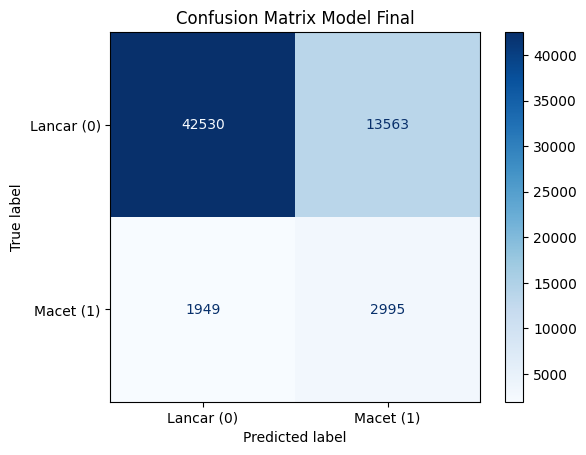

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Training Ulang Model Final
model_lgb_final = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

model_lgb_final.fit(X_train_final, y_train)

# Prediksi
y_pred_final = model_lgb_final.predict(X_test_final) # Untuk Class (0 atau 1)
y_prob_final = model_lgb_final.predict_proba(X_test_final)[:, 1] # Untuk AUC

custom_threshold = 0.6
y_pred_custom = (y_prob_final >= custom_threshold).astype(int)


# Cetak Skor
print(f"Final AUC: {roc_auc_score(y_test, y_prob_final):.4f}")
print("-" * 30)
print(classification_report(y_test, y_pred_custom))

# Visualisasi Confusion Matrix
disp = ConfusionMatrixDisplay.from_estimator(
    model_lgb_final, X_test_final, y_test,
    display_labels=['Lancar (0)', 'Macet (1)'],
    cmap='Blues'
)
plt.title("Confusion Matrix Model Final")
plt.show()

Threshold Optimal (F1-Max): 0.6402
Precision pada threshold ini: 0.2438
Recall pada threshold ini: 0.4055


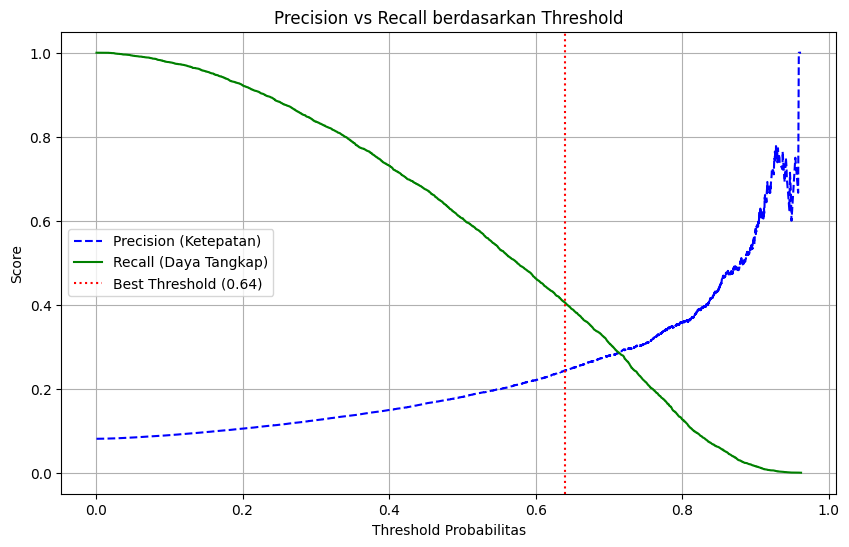

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# 1. Ambil probabilitas untuk kelas 1 (Macet)
y_scores = model_lgb_final.predict_proba(X_test_final)[:, 1]

# 2. Hitung precision, recall, dan thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# 3. Cari F1-Score untuk setiap threshold
# F1 = 2 * (precision * recall) / (precision + recall)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Threshold Optimal (F1-Max): {best_threshold:.4f}")
print(f"Precision pada threshold ini: {precisions[best_idx]:.4f}")
print(f"Recall pada threshold ini: {recalls[best_idx]:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision (Ketepatan)')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall (Daya Tangkap)')
plt.axvline(best_threshold, color='red', linestyle=':', label=f'Best Threshold ({best_threshold:.2f})')
plt.xlabel('Threshold Probabilitas')
plt.ylabel('Score')
plt.title('Precision vs Recall berdasarkan Threshold')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# 1. Definisikan Objective Function untuk Optuna
def objective(trial):
    # Parameter space yang akan dijelajahi
    param = {
        'n_estimators': 2000, # Kita gunakan angka tinggi dengan Early Stopping nanti
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 0.9),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 0.9),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'class_weight': 'balanced',
        'random_state': 42,
        'importance_type': 'gain',
        'n_jobs': -1,
        'verbose': -1
    }

    # Gunakan StratifiedKFold agar pembagian kelas 0 dan 1 tetap proporsional
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Buat model dengan parameter dari trial
    model = LGBMClassifier(**param)

    # Hitung skor AUC menggunakan Cross Validation
    # Kita gunakan X_train_final dari hasil seleksi fitur kamu sebelumnya
    scores = cross_val_score(model, X_train_final, y_train, cv=cv, scoring='roc_auc')

    return scores.mean()

# 2. Jalankan Proses Optimasi
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30) # Coba 30 kombinasi berbeda

print(f"Best AUC from Optuna: {study.best_value:.4f}")
print("Best Parameters:", study.best_params)

# 3. Training Ulang Model dengan Parameter Terbaik
best_params = study.best_params
final_model = LGBMClassifier(**best_params, n_estimators=3000, class_weight='balanced', verbose=-1)

# Gunakan Early Stopping secara manual jika memungkinkan atau gunakan fit biasa
final_model.fit(X_train_final, y_train)

# 4. Evaluasi Akhir pada Test Set
final_probs = final_model.predict_proba(X_test_final)[:, 1]
print(f"Final Test AUC: {roc_auc_score(y_test, final_probs):.4f}")

[I 2026-04-03 12:09:59,764] A new study created in memory with name: no-name-35b45967-02f4-487f-aace-ec37c7debc51
[I 2026-04-03 12:18:02,903] Trial 0 finished with value: 0.7367490058967998 and parameters: {'learning_rate': 0.04476015210845281, 'num_leaves': 135, 'max_depth': 6, 'min_child_samples': 56, 'feature_fraction': 0.7220582794185684, 'bagging_fraction': 0.4200941915167186, 'bagging_freq': 2, 'reg_alpha': 0.006824727196801394, 'reg_lambda': 0.0026746269590094494}. Best is trial 0 with value: 0.7367490058967998.
[I 2026-04-03 12:26:27,349] Trial 1 finished with value: 0.7549696961229705 and parameters: {'learning_rate': 0.006876650317289769, 'num_leaves': 28, 'max_depth': 7, 'min_child_samples': 64, 'feature_fraction': 0.513975543500371, 'bagging_fraction': 0.45126684237468606, 'bagging_freq': 6, 'reg_alpha': 0.49302151159120544, 'reg_lambda': 0.7246871115735507}. Best is trial 1 with value: 0.7549696961229705.
[I 2026-04-03 12:34:54,097] Trial 2 finished with value: 0.752627640